# Sprint 1 -- Pre-processing and Exploratory Data Analysis


This notebook establishes the preprocessing, exploratory data analysis, and feature engineering foundations for the CRM-to-Billing configuration prediction task. It implements two distinct data preparation paradigms for direct empirical comparison in Sprint 2:
1. **Section 10 (Baseline Heuristic Cleaning):** The initial exploratory cleaning strategy employing pairwise correlation pruning and majority-vote configuration relabeling.
2. **Section 11 (Multi-Label Pipeline):** An advanced, statistically grounded multi-label methodology featuring asymptotic variance filtering, hypothesis space reduction via deterministic additive target isolation, vectorized $\chi^2$ feature selection with Benjamini-Hochberg FDR control, and dynamically-sized sparse TruncatedSVD ($\ge 80\%$ cumulative variance).


## 0. Setup

In [1]:
import os
import re
from collections import defaultdict, Counter

# Set before sklearn/joblib are imported anywhere, otherwise the community-detection
# step later in the notebook fills the output with harmless but distracting
# 'Could not find the number of physical cores' / MKL memory-leak warnings on Windows.
os.environ.setdefault('OMP_NUM_THREADS', '6')
os.environ.setdefault('LOKY_MAX_CPU_COUNT', '6')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display  # injected by Jupyter but not by nbconvert / plain
                                      # python; importing explicitly keeps the notebook
                                      # runnable both ways.

pd.set_option('display.max_columns', 50)

DATA_DIR = '../data'
DERIVED_DIR = f'{DATA_DIR}/derived'
os.makedirs(DERIVED_DIR, exist_ok=True)

RNG = np.random.default_rng(42)


Every summary produced in this notebook is written to `data/derived/` through a single
`save()` helper, rather than through scattered `to_csv` calls. `save()` both writes the
file and records it in `EXPORTS`, so the manifest built in the final section is generated
from what actually ran, not maintained by hand: if a cell is skipped or fails, its file is
simply absent from the manifest, which makes a partial run visible rather than silent.

In [2]:
EXPORTS = []


def save(obj, name, index=False):
    """Write a derived summary and register it in the manifest. One source of truth per file."""
    df = obj if isinstance(obj, pd.DataFrame) else pd.DataFrame(obj)
    df.to_csv(f'{DERIVED_DIR}/{name}', index=index)
    EXPORTS.append({'file': name, 'rows': len(df), 'cols': int(df.shape[1])})
    return df

`np.packbits` encodes each row's bit pattern into 94 bytes. This key is exact and
collision-free -- it is the data itself, not a hash -- and roughly two orders of magnitude
faster to compute than joining 745 string values per row. It is used throughout the
notebook (Sections 3, 3b, 3c, 6b, 8b) wherever rows need to be compared or grouped by
their exact configuration.

`cooc` accumulates column-by-column co-occurrence counts over row chunks, so the full
730 x 717 CRM-BIL association matrix can be computed on all 187,442 rows without holding a
dense floating-point copy of the data in memory. This removes the need for the 30,000-row
subsample that a naive dense correlation matrix would otherwise require.

In [3]:
def row_keys(A):
    """Exact identity of each row of a 0/1 matrix, as bytes (no hashing, no collisions)."""
    return [r.tobytes() for r in np.packbits(A, axis=1)]


def col_keys(A):
    """Same, per column — used in 6b to find columns that are literally identical."""
    return [c.tobytes() for c in np.packbits(np.ascontiguousarray(A.T), axis=1)]


def factorize_rows(A):
    """Integer code per distinct configuration, plus the number of distinct ones."""
    keys = row_keys(A)
    codes, uniq = pd.factorize(pd.Series(keys), sort=False)
    return codes.astype(np.int64), len(uniq), keys


def cooc(A, B, chunk=20000):
    """Column-by-column co-occurrence counts between two 0/1 matrices, chunked by rows."""
    out = np.zeros((A.shape[1], B.shape[1]), np.float64)
    for s in range(0, len(A), chunk):
        out += A[s:s + chunk].astype(np.float32).T @ B[s:s + chunk].astype(np.float32)
    return out

The three functions below -- referential integrity checks, IQR-based pack-count outlier
flagging, and activation-rate imbalance tiering -- are used in several sections and are
defined once here.

In [4]:
def referential_integrity_checks(train, test, crm_cols, bil_cols):
    out = {}
    out['columns_match'] = [c for c in test.columns if c != 'MSISDN'] == crm_cols
    assert out['columns_match'], 'test CRM columns differ from train'
    out['train_binary_only'] = bool(train[crm_cols + bil_cols].to_numpy().max() <= 1)
    out['test_binary_only'] = bool(test[crm_cols].to_numpy().max() <= 1)
    assert out['train_binary_only'] and out['test_binary_only'], 'non-binary values present'
    out['train_nulls'] = int(train.isna().sum().sum())
    out['test_nulls'] = int(test.isna().sum().sum())
    assert out['train_nulls'] == 0 and out['test_nulls'] == 0, 'nulls present'
    out['n_duplicate_msisdn_train'] = int(train['MSISDN'].duplicated().sum())
    out['n_duplicate_msisdn_test'] = int(test['MSISDN'].duplicated().sum())
    out['n_msisdn_overlap_train_test'] = len(set(train['MSISDN']) & set(test['MSISDN']))
    return out


def flag_count_outliers(s):
    q1, q3 = s.quantile(.25), s.quantile(.75)
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    return (s < lo) | (s > hi), lo, hi


def label_imbalance_report(rates):
    labels = ['ultra_rare(<0.1%)', 'rare(0.1-1%)', 'uncommon(1-10%)',
              'common(10-50%)', 'dense(>=50%)']
    tier = pd.cut(rates, bins=[-1, .001, .01, .10, .50, 1.01], labels=labels)
    return (tier.value_counts().reindex(labels)
            .rename_axis('imbalance_tier').reset_index(name='n_columns'))


## 1. Load the data

The raw files are large (`train.csv` approximately 560MB, `test.csv` approximately
148MB). Every column except the row identifier is binary, so both files are loaded with
an explicit `int8` dtype map -- 284MB in memory instead of roughly 2.1GB under the pandas
default `int64`.

Identifier columns are derived from the header (any column that is neither `CRM*` nor
`BIL*`) rather than hardcoded as `MSISDN`, so the dtype map does not silently break if the
file ever ships an additional non-numeric column.

In [5]:
header = pd.read_csv(f'{DATA_DIR}/train.csv', nrows=0).columns.tolist()
crm_cols = [c for c in header if c.startswith('CRM')]
bil_cols = [c for c in header if c.startswith('BIL')]
id_cols = [c for c in header if c not in set(crm_cols) | set(bil_cols)]  # derived, not hardcoded

print(f'{len(crm_cols)} CRM columns, {len(bil_cols)} BIL columns, {len(header)} total')
print('identifier columns:', id_cols)

dtype_map = {c: 'int8' for c in crm_cols + bil_cols}
for c in id_cols:
    dtype_map[c] = str

train = pd.read_csv(f'{DATA_DIR}/train.csv', dtype=dtype_map)
print('train shape:', train.shape, f'({train.memory_usage(deep=False).sum()/1e6:.0f} MB)')
train.head()

745 CRM columns, 731 BIL columns, 1477 total
identifier columns: ['MSISDN']
train shape: (187442, 1477) (284 MB)


,MSISDN,CRM_BUSINESS_LINE_ORIG_Mobile,CRM_1519_PACK,CRM_1521_PACK,CRM_1522_PACK,CRM_1523_PACK,CRM_1524_PACK,CRM_1525_PACK,CRM_1526_PACK,CRM_1527_PACK,CRM_1528_PACK,CRM_1529_PACK,CRM_1530_PACK,CRM_1532_PACK,CRM_1533_PACK,CRM_1534_PACK,CRM_1536_PACK,CRM_1537_PACK,CRM_1538_PACK,CRM_1539_PACK,CRM_1540_PACK,CRM_1541_PACK,CRM_1542_PACK,CRM_1543_PACK,CRM_1545_PACK,...,BIL_4449_PACK,BIL_4450_PACK,BIL_4451_PACK,BIL_4452_PACK,BIL_4454_PACK,BIL_4455_PACK,BIL_4456_PACK,BIL_4457_PACK,BIL_4458_PACK,BIL_4459_PACK,BIL_4460_PACK,BIL_4461_PACK,BIL_4462_PACK,BIL_4463_PACK,BIL_4464_PACK,BIL_4465_PACK,BIL_4466_PACK,BIL_4467_PACK,BIL_4468_PACK,BIL_4504_PACK,BIL_4506_PACK,BIL_4507_PACK,BIL_4508_PACK,BIL_4509_PACK,BIL_4510_PACK
0,4f1b9e575ac7ea93b4a978b3095d7ee1,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0,1,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,01908281632545a2fc22d4a6365f2b27,1,0,0,0,0,0,0,0,0,0,1,0,1,1,1,1,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,f6f0c782716d8928928407c4e426be25,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,a543952f2405c440fc40f85e8adfdfd6,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,63e3cdf2eff067ce9af9f9f8530b16eb,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,1,0,1,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [6]:
test_dtype_map = {c: 'int8' for c in crm_cols}
for c in id_cols:
    test_dtype_map[c] = str

test = pd.read_csv(f'{DATA_DIR}/test.csv', dtype=test_dtype_map)
print('test shape:', test.shape, f'({test.memory_usage(deep=False).sum()/1e6:.0f} MB)')
test.head()

test shape: (97100, 746) (76 MB)


,MSISDN,CRM_BUSINESS_LINE_ORIG_Mobile,CRM_1519_PACK,CRM_1521_PACK,CRM_1522_PACK,CRM_1523_PACK,CRM_1524_PACK,CRM_1525_PACK,CRM_1526_PACK,CRM_1527_PACK,CRM_1528_PACK,CRM_1529_PACK,CRM_1530_PACK,CRM_1532_PACK,CRM_1533_PACK,CRM_1534_PACK,CRM_1536_PACK,CRM_1537_PACK,CRM_1538_PACK,CRM_1539_PACK,CRM_1540_PACK,CRM_1541_PACK,CRM_1542_PACK,CRM_1543_PACK,CRM_1545_PACK,...,CRM_2370_PACK,CRM_2371_PACK,CRM_2372_PACK,CRM_2373_PACK,CRM_2374_PACK,CRM_2375_PACK,CRM_2376_PACK,CRM_2377_PACK,CRM_2378_PACK,CRM_2379_PACK,CRM_2380_PACK,CRM_2381_PACK,CRM_2382_PACK,CRM_2383_PACK,CRM_2385_PACK,CRM_2387_PACK,CRM_2388_PACK,CRM_2389_PACK,CRM_2391_PACK,CRM_2392_PACK,CRM_2394_PACK,CRM_2395_PACK,CRM_2396_PACK,CRM_2397_PACK,CRM_2398_PACK
0,db67b03cf9fb8ea96077cd34c7a28139,1,0,1,1,1,0,0,1,1,1,1,0,1,1,0,1,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2ac0d310d5cf1a96587af614d37b8b54,1,0,0,0,0,0,0,0,0,0,1,0,1,1,0,0,1,1,0,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,a8f289fbd263794ac74059a18c1d10a5,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,5a53a1c85ccc7e794c90c75b75b8d3cb,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,484b400226b8894377e12204219283fc,1,0,0,0,0,0,0,0,0,1,1,0,1,1,0,1,0,0,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## 2. Basic sanity checks

The mean of the per-column activation rates is reported alongside its row-level reading:
the *sum* of the column means is the expected number of active columns per customer,
which is the quantity the rest of the notebook reasons about, so both are exported.

In [7]:
crm_rate_all = train[crm_cols].mean()
bil_rate_all = train[bil_cols].mean()

print('Missing values in train:', train.isna().sum().sum())
print('Missing values in test:', test.isna().sum().sum())
print('Duplicate MSISDN in train:', train['MSISDN'].duplicated().sum())
print('Duplicate MSISDN in test:', test['MSISDN'].duplicated().sum())
print(f'\nMean activation rate, CRM columns: {crm_rate_all.mean():.4f}'
      f'   -> {crm_rate_all.sum():.2f} active CRM columns per customer')
print(f'Mean activation rate, BIL columns: {bil_rate_all.mean():.4f}'
      f'   -> {bil_rate_all.sum():.2f} active BIL columns per customer')

save([{
    'n_train_rows': len(train), 'n_test_rows': len(test),
    'missing_values_train': int(train.isna().sum().sum()),
    'missing_values_test': int(test.isna().sum().sum()),
    'duplicate_msisdn_train': int(train['MSISDN'].duplicated().sum()),
    'duplicate_msisdn_test': int(test['MSISDN'].duplicated().sum()),
    'mean_crm_activation_rate': round(float(crm_rate_all.mean()), 6),
    'mean_bil_activation_rate': round(float(bil_rate_all.mean()), 6),
    # per-customer reading, used throughout the rest of the notebook
    'mean_active_crm_columns_per_customer': round(float(crm_rate_all.sum()), 4),
    'mean_active_bil_columns_per_customer': round(float(bil_rate_all.sum()), 4),
}], 'basic_sanity.csv');

Missing values in train: 0
Missing values in test: 0
Duplicate MSISDN in train: 0
Duplicate MSISDN in test: 0

Mean activation rate, CRM columns: 0.0205   -> 15.29 active CRM columns per customer
Mean activation rate, BIL columns: 0.0201   -> 14.69 active BIL columns per customer


In [8]:
crm_var = train[crm_cols].nunique()
bil_var = train[bil_cols].nunique()
constant_crm = crm_var[crm_var <= 1].index.tolist()
constant_bil = bil_var[bil_var <= 1].index.tolist()

print(f'Constant (zero-variance) CRM columns: {len(constant_crm)} / {len(crm_cols)}  {constant_crm}')
print(f'Constant (zero-variance) BIL columns: {len(constant_bil)} / {len(bil_cols)}  {constant_bil}')
print('\nNOTE: a constant CRM column is a safe drop. A constant BIL column would NOT be')
print('      droppable — all 731 targets must still be emitted for EMR — merely free to')
print('      predict. There are none, so the point is moot, but the asymmetry matters.')

save([{'system': 'CRM', 'column': c} for c in constant_crm]
     + [{'system': 'BIL', 'column': c} for c in constant_bil]
     or [{'system': None, 'column': None}], 'constant_columns.csv');

Constant (zero-variance) CRM columns: 2 / 745  ['CRM_2396_PACK', 'CRM_2398_PACK']
Constant (zero-variance) BIL columns: 0 / 731  []

NOTE: a constant CRM column is a safe drop. A constant BIL column would NOT be
      droppable — all 731 targets must still be emitted for EMR — merely free to
      predict. There are none, so the point is moot, but the asymmetry matters.


## 2b. Referential integrity checks

CRM and BIL are already columns of the same row per `MSISDN`, not separate tables to be
joined, so there is no classical orphaned-foreign-key risk in this dataset. The risks that
remain are schema drift between train and test and stray non-binary values, either of
which would silently break the downstream pipeline. These are therefore implemented as
hard assertions rather than diagnostics.

In [9]:
integrity = referential_integrity_checks(train, test, crm_cols, bil_cols)
print('All hard integrity checks passed (would have raised AssertionError otherwise):')
for k, v in integrity.items():
    print(f'  {k}: {v}')

save([integrity], 'referential_integrity.csv');

All hard integrity checks passed (would have raised AssertionError otherwise):
  columns_match: True
  train_binary_only: True
  test_binary_only: True
  train_nulls: 0
  test_nulls: 0
  n_duplicate_msisdn_train: 0
  n_duplicate_msisdn_test: 0
  n_msisdn_overlap_train_test: 0


The checks above confirm that the two files share a *schema*. They say nothing about
whether the two files share a *distribution*, which matters for two reasons: material
differences in the CRM marginals between train and test would indicate covariate shift,
against which anything fitted on train would transfer poorly; and the share of test rows
whose exact CRM configuration already appears in train determines whether a lookup-based
approach is viable at all, which constrains the space of Sprint 2 model designs.

Only test *features* are used in this check; the test billing labels are not present in
the file, so no label information can leak.

In [10]:
p_tr = train[crm_cols].mean().to_numpy()
p_te = test[crm_cols].mean().to_numpy()
marg_corr = float(np.corrcoef(p_tr, p_te)[0, 1])
print(f'CRM marginals train vs test: corr={marg_corr:.6f}   '
      f'max|diff|={np.abs(p_tr - p_te).max():.5f}   mean|diff|={np.abs(p_tr - p_te).mean():.6f}')
print('columns with |diff| > 0.01:', int((np.abs(p_tr - p_te) > .01).sum()))

seen_tr = train[crm_cols].to_numpy(np.uint8).any(0)
seen_te = test[crm_cols].to_numpy(np.uint8).any(0)
print('CRM columns active in test but never in train:', int((seen_te & ~seen_tr).sum()))
print('CRM columns active in train but never in test:', int((seen_tr & ~seen_te).sum()))

train_cfg_keys = set(row_keys(train[crm_cols].to_numpy(np.uint8)))
test_cfg_keys = row_keys(test[crm_cols].to_numpy(np.uint8))
hit = sum(1 for k in test_cfg_keys if k in train_cfg_keys)
print(f'\ntest rows whose exact CRM configuration appears in train: '
      f'{hit:,} / {len(test_cfg_keys):,} ({hit/len(test_cfg_keys):.4%})')

# A marginal correlation of ~0.95 with a max gap of ~0.24 is not the near-identity one
# would assume from the correlation alone, so the affected columns are named explicitly.
shift = pd.DataFrame({'crm_column': crm_cols, 'prevalence_train': p_tr,
                      'prevalence_test': p_te, 'diff': p_te - p_tr})
shift['abs_diff'] = shift['diff'].abs()
shift['train_only'] = seen_tr & ~seen_te
shift['test_only'] = seen_te & ~seen_tr
print('\nlargest train/test marginal shifts:')
display(shift.sort_values('abs_diff', ascending=False).head(12).round(5))
print('columns active in TEST only:', shift.loc[shift.test_only, 'crm_column'].tolist())
print('columns active in TRAIN only:', shift.loc[shift.train_only, 'crm_column'].tolist()[:12])
save(shift.sort_values('abs_diff', ascending=False), 'train_test_marginal_shift.csv')

save([{
    'crm_marginal_corr_train_test': round(marg_corr, 6),
    'max_abs_marginal_diff': round(float(np.abs(p_tr - p_te).max()), 6),
    'mean_abs_marginal_diff': round(float(np.abs(p_tr - p_te).mean()), 8),
    'n_cols_marginal_diff_gt_0.01': int((np.abs(p_tr - p_te) > .01).sum()),
    'n_cols_active_test_only': int((seen_te & ~seen_tr).sum()),
    'n_cols_active_train_only': int((seen_tr & ~seen_te).sum()),
    'n_test_rows': len(test_cfg_keys),
    'n_test_rows_with_exact_crm_config_in_train': int(hit),
    'pct_test_rows_covered_by_lookup': round(hit / len(test_cfg_keys), 8),
}], 'train_test_drift.csv');

CRM marginals train vs test: corr=0.950678   max|diff|=0.24388   mean|diff|=0.008117
columns with |diff| > 0.01: 85
CRM columns active in test but never in train: 2
CRM columns active in train but never in test: 33

test rows whose exact CRM configuration appears in train: 6 / 97,100 (0.0062%)

largest train/test marginal shifts:


,crm_column,prevalence_train,prevalence_test,diff,abs_diff,train_only,test_only
10,CRM_1529_PACK,0.52003,0.76391,0.24388,0.24388,False,False
21,CRM_1542_PACK,0.52092,0.76456,0.24364,0.24364,False,False
13,CRM_1533_PACK,0.52091,0.76454,0.24363,0.24363,False,False
20,CRM_1541_PACK,0.51901,0.76041,0.24140,0.24140,False,False
12,CRM_1532_PACK,0.51462,0.74820,0.23357,0.23357,False,False
134,CRM_2076_PACK,0.42846,0.23029,-0.19817,0.19817,False,False
135,CRM_2077_PACK,0.42322,0.22577,-0.19745,0.19745,False,False
145,CRM_2087_PACK,0.41741,0.22969,-0.18772,0.18772,False,False
146,CRM_2088_PACK,0.40210,0.21898,-0.18312,0.18312,False,False
8,CRM_1527_PACK,0.28113,0.44358,0.16245,0.16245,False,False


columns active in TEST only: ['CRM_2396_PACK', 'CRM_2398_PACK']
columns active in TRAIN only: ['CRM_2145_PACK', 'CRM_1866_PACK', 'CRM_2208_PACK', 'CRM_1891_PACK', 'CRM_1904_PACK', 'CRM_2252_PACK', 'CRM_2272_PACK', 'CRM_2279_PACK', 'CRM_2282_PACK', 'CRM_2284_PACK', 'CRM_2292_PACK', 'CRM_2293_PACK']


## 3. The CRM to Billing relationship

The case study brief makes three structural claims about this relationship: the mapping
can be many-to-one, the individual variables may not correspond one-to-one, and the
training data contains provisioning errors. This section measures all three directly, at
the level of the exact configuration (not a single representative column), and states the
consequences that follow -- the EMR ceiling implied by a perfect lookup, the per-row
provisioning error rate, and the resulting validation-design requirement -- rather than
deferring them to the summary.

In [11]:
Xc = train[crm_cols].to_numpy(np.uint8)
Yc = train[bil_cols].to_numpy(np.uint8)

crm_code, n_crm_cfg, crm_keys = factorize_rows(Xc)
bil_code, n_bil_cfg, bil_keys = factorize_rows(Yc)
pairs = pd.DataFrame({'crm': crm_code, 'bil': bil_code})

n_rows = len(pairs)
n_dup = int(pairs.duplicated().sum())

print(f'rows                              {n_rows:,}')
print(f'distinct CRM configurations       {n_crm_cfg:,}')
print(f'distinct BIL configurations       {n_bil_cfg:,}')
print(f'fully duplicated (CRM,BIL) rows   {n_dup:,}  ({n_dup/n_rows:.2%})')
print(f'distinct (CRM,BIL) pairs          {n_rows - n_dup:,}')

size = pairs.groupby('crm')['bil'].size()
nuniq = pairs.groupby('crm')['bil'].nunique()
modal = pairs.groupby(['crm', 'bil']).size().groupby('crm').max()

# first occurrence of each configuration code -> a representative row index.
# Defined here (not later) so 3c, 5b, 7d, 8 and 8b do not depend on each other's order.
first_x = pd.Series(np.arange(len(crm_code))).groupby(crm_code).first()
first_y = pd.Series(np.arange(len(bil_code))).groupby(bil_code).first()

rows                              187,442
distinct CRM configurations       67,434
distinct BIL configurations       67,201
fully duplicated (CRM,BIL) rows   119,264  (63.63%)
distinct (CRM,BIL) pairs          68,178


The duplication count, the configuration count and the ambiguity distribution below are
three independent views of the same partition of rows, so they must agree exactly. This
also serves as an internal check that the `packbits` keying is exact: an approximate
identity function would not reconcile to the row.

In [12]:
extra = int((nuniq - 1).sum())
reconciles = (n_crm_cfg + extra == n_rows - n_dup)
print(f'distinct CRM configs           {n_crm_cfg:,}')
print(f'extra BIL per ambiguous config {extra:,}')
print(f'check: {n_crm_cfg:,} + {extra:,} = {n_crm_cfg + extra:,}   '
      f'vs distinct (CRM,BIL) pairs {n_rows - n_dup:,}   '
      f"{'OK' if reconciles else 'MISMATCH'}")
assert reconciles, 'configuration keying is not exact'

distinct CRM configs           67,434
extra BIL per ambiguous config 744
check: 67,434 + 744 = 68,178   vs distinct (CRM,BIL) pairs 68,178   OK


In [13]:
n_amb_cfg = int((nuniq > 1).sum())
n_amb_rows = int(size[nuniq > 1].sum())

print(f'CRM configs mapping to >1 BIL config: {n_amb_cfg:,} / {n_crm_cfg:,} '
      f'({n_amb_cfg/n_crm_cfg:.2%} of configurations)')
print(f'  ... but they cover               : {n_amb_rows:,} / {n_rows:,} '
      f'({n_amb_rows/n_rows:.2%} of ROWS)')
print('\nThe configuration-level share understates the practical impact of ambiguity,')
print('since ambiguity concentrates in the more frequent configurations.')

dist = (nuniq.value_counts().sort_index()
        .rename_axis('n_bil_configs_per_crm_config').reset_index(name='n_crm_configs'))
print('\n#BIL configs per CRM config:')
print(dist.head(12).to_string(index=False))
save(dist, 'bil_per_crm_config_distribution.csv')

modal_share = modal / size
if n_amb_cfg:
    q = np.quantile(modal_share[nuniq > 1], [.05, .25, .5, .75, .95])
    print(f'\nmodal share within ambiguous groups (.05,.25,.5,.75,.95): {np.round(q, 3)}')
    print(f'groups that are an exact 50/50 split: {int((modal_share[nuniq > 1] <= 0.5).sum()):,}')

CRM configs mapping to >1 BIL config: 617 / 67,434 (0.91% of configurations)
  ... but they cover               : 58,402 / 187,442 (31.16% of ROWS)

The configuration-level share understates the practical impact of ambiguity,
since ambiguity concentrates in the more frequent configurations.

#BIL configs per CRM config:
 n_bil_configs_per_crm_config  n_crm_configs
                            1          66817
                            2            532
                            3             69
                            4              6
                            5              2
                            6              4
                            7              2
                            8              1
                           10              1

modal share within ambiguous groups (.05,.25,.5,.75,.95): [0.5   0.667 0.867 0.967 0.996]
groups that are an exact 50/50 split: 104


The accuracy of a perfect exact-match lookup that resolves every conflicting
configuration by majority vote is a computable ceiling on EMR, and the complement of that
ceiling is a per-row provisioning error rate, rather than a qualitative statement that
provisioning errors exist.

One qualification is necessary: an error is only detectable in a configuration that
repeats. The overwhelming majority of configurations are observed exactly once, so the
rate estimated on repeated configurations is a lower bound on the error rate for the
dataset as a whole.

In [14]:
ceiling = float(modal.sum() / n_rows)
n_nonmodal = int(n_rows - modal.sum())
n_repeated_rows = int(size[size > 1].sum())
n_singleton_cfg = int((size == 1).sum())
err_rate = n_nonmodal / n_repeated_rows

print(f'EMR CEILING (exact-match lookup, majority vote)  {ceiling:.4f}')
print(f'non-modal rows                                   {n_nonmodal:,}')
print(f'rows living in repeated configurations           {n_repeated_rows:,}')
print(f'=> per-row provisioning error rate               {err_rate:.4f}')
print(f'\nsingleton configurations: {n_singleton_cfg:,} '
      f'({n_singleton_cfg/n_crm_cfg:.1%} of configs, {n_singleton_cfg/n_rows:.2%} of rows)')
print('   -> errors inside singletons are UNDETECTABLE, so the rate above is a LOWER BOUND.')

rev = pairs.groupby('bil')['crm'].nunique()
print(f'\nmany-to-one (the brief\'s first claim), measured:')
print(f'  distinct BIL configurations           {len(rev):,}')
print(f'  fed by >1 CRM configuration           {int((rev > 1).sum()):,} ({(rev > 1).mean():.2%})')
print(f'  max CRM configurations -> one billing {int(rev.max())}')
print('  -> real but RARE; the map is overwhelmingly one-to-one at configuration level.')

save([{
    'n_rows': n_rows,
    'n_unique_crm_configs': n_crm_cfg,
    'n_unique_bil_configs': n_bil_cfg,
    'n_duplicate_rows': n_dup,
    'pct_duplicate_rows': round(n_dup / n_rows, 6),
    'n_distinct_crm_bil_pairs': n_rows - n_dup,
    'reconciliation_ok': bool(reconciles),
    'n_ambiguous_crm_configs': n_amb_cfg,
    'pct_ambiguous_crm_configs': round(n_amb_cfg / n_crm_cfg, 6),
    'n_rows_in_ambiguous_configs': n_amb_rows,
    'pct_rows_in_ambiguous_configs': round(n_amb_rows / n_rows, 6),
    'emr_ceiling_exact_lookup': round(ceiling, 6),
    'n_nonmodal_rows': n_nonmodal,
    'per_row_provisioning_error_rate_lower_bound': round(err_rate, 6),
    'n_singleton_configs': n_singleton_cfg,
    'pct_rows_in_singleton_configs': round(n_singleton_cfg / n_rows, 6),
    'n_bil_configs_fed_by_multiple_crm': int((rev > 1).sum()),
    'pct_bil_configs_fed_by_multiple_crm': round(float((rev > 1).mean()), 6),
    'max_crm_configs_per_bil_config': int(rev.max()),
}], 'crm_bil_relationship_summary.csv');

EMR CEILING (exact-match lookup, majority vote)  0.9930
non-modal rows                                   1,315
rows living in repeated configurations           129,589
=> per-row provisioning error rate               0.0101

singleton configurations: 57,853 (85.8% of configs, 30.86% of rows)
   -> errors inside singletons are UNDETECTABLE, so the rate above is a LOWER BOUND.

many-to-one (the brief's first claim), measured:
  distinct BIL configurations           67,201
  fed by >1 CRM configuration           873 (1.30%)
  max CRM configurations -> one billing 24
  -> real but RARE; the map is overwhelmingly one-to-one at configuration level.


## 3b. Consequence for the Sprint 2 validation design

This is the most consequential conclusion for Sprint 2 modelling, and it follows directly
from the duplication rate measured above. A large share of rows are exact repeats of
another (CRM, Billing) pair; under a random *row* split, a validation row whose
configuration has multiplicity `m` has a training-set twin with probability
`1 - 0.2^(m-1)`. Such rows are answerable by memorisation rather than generalisation, so a
reported validation EMR under a random row split converges toward the lookup ceiling
rather than measuring the model's ability to generalise.

The train/validation split must therefore be grouped on the CRM configuration code
(`GroupKFold` or `GroupShuffleSplit` with `groups` set to the configuration code), and any
weighting scheme should be considered at the level of distinct configurations rather than
rows. Stratifying by a customer segment does not address this, since segment membership is
orthogonal to configuration duplication.

In [15]:
mult = size.reindex(pairs['crm']).to_numpy()
p_twin = 1 - 0.2 ** np.maximum(mult - 1, 0)
share_memorisable = float(p_twin.mean())

# 0.86 is a placeholder for "what a real model achieves on unseen configurations". It is used
# only to show the SIZE of the gap, not to claim a score.
GENERALISATION_GUESS = 0.86
inflated = share_memorisable * ceiling + (1 - share_memorisable) * GENERALISATION_GUESS
se_factor = float(np.sqrt(n_rows / n_crm_cfg))

print(f'expected share of validation rows answerable by exact lookup '
      f'under a random ROW split: {share_memorisable:.2%}')
print(f'=> such a split would report roughly EMR {inflated:.3f} '
      f'against a true ~{GENERALISATION_GUESS:.3f}')
print(f'\neffective sample size: {n_crm_cfg:,} configurations, not {n_rows:,} rows')
print(f'row-wise standard errors are too narrow by a factor of {se_factor:.2f}')

save([{
    'n_rows': n_rows,
    'effective_sample_size_configs': n_crm_cfg,
    'mean_config_multiplicity': round(n_rows / n_crm_cfg, 4),
    'share_val_rows_memorisable_under_row_split': round(share_memorisable, 6),
    'emr_a_row_split_would_report': round(float(inflated), 4),
    'generalisation_placeholder_used': GENERALISATION_GUESS,
    'standard_error_inflation_factor': round(se_factor, 4),
    'required_split': 'GroupKFold / GroupShuffleSplit on crm_code',
}], 'validation_design.csv');

expected share of validation rows answerable by exact lookup under a random ROW split: 68.23%
=> such a split would report roughly EMR 0.951 against a true ~0.860

effective sample size: 67,434 configurations, not 187,442 rows
row-wise standard errors are too narrow by a factor of 1.67


## 3c. Is the within-configuration variation an error, or a mechanism?

"Provisioning error" is the language used in the case study brief; it does not by itself
establish that all within-configuration variation is unstructured noise. A billing-side
attribute that is not a deterministic function of the CRM commercial configuration -- a
promotion, a discount, or a status captured at a different moment by the two systems --
would produce the same signature: an identical CRM configuration mapping to more than one
Billing configuration.

The two hypotheses make different, testable predictions. Under random error, the columns
that differ within a repeated configuration should be distributed roughly in proportion to
their prevalence, and the specific pattern of differing columns should rarely recur across
independent pairs. Under a systematic mechanism, a small number of columns should account
for most of the differences, the symmetric difference between variants should typically be
small (one or two bits, consistent with a single flag toggling rather than a wholesale
change in billing outcome), and the same difference pattern should recur.

This distinction determines the correct cleaning rule: a majority vote is appropriate for
random error, and is not appropriate for a systematic mechanism, since in that case the
minority variant is the correct label for its customer, not noise to be corrected away.

In [16]:
multi_cfg = size[size > 1].index
m = np.isin(crm_code, multi_cfg)

# a column varies inside a configuration iff its group sum is strictly between 0 and the group
# size. One groupby-sum instead of a max and a min — the heaviest cell in the notebook.
gm = pd.DataFrame(Yc[m], index=crm_code[m])
sums = gm.groupby(level=0).sum()
cnts = gm.groupby(level=0).size().to_numpy()[:, None]
varies = (sums.to_numpy() > 0) & (sums.to_numpy() < cnts)
rate = pd.Series(varies.mean(0), index=bil_cols)

top = rate.sort_values(ascending=False).head(20)
print('BIL columns that vary most within an IDENTICAL CRM configuration:')
for c, v in top.items():
    print(f'  {c:>42}  varies in {v:.5f} of repeated configs   prev={bil_rate_all[c]:.4f}')
print(f'\nshare of all variation held by the top 1 / 5 / 20 columns: '
      f'{top.head(1).sum()/rate.sum():.3f} / {top.head(5).sum()/rate.sum():.3f} '
      f'/ {top.head(20).sum()/rate.sum():.3f}')
print(f'overall (config, column) inconsistency rate: {varies.mean():.6f}')

save(pd.DataFrame({'bil_column': rate.index,
                   'varies_in_share_of_repeated_configs': rate.to_numpy().round(8),
                   'prevalence': bil_rate_all.reindex(rate.index).to_numpy().round(8)})
     .sort_values('varies_in_share_of_repeated_configs', ascending=False),
     'within_config_variation_by_column.csv');

BIL columns that vary most within an IDENTICAL CRM configuration:
                               BIL_3803_PACK  varies in 0.01033 of repeated configs   prev=0.0036
                               BIL_3940_PACK  varies in 0.00835 of repeated configs   prev=0.0045
           BIL_SUBSCRIBER_STATUS_ORIG_Active  varies in 0.00772 of repeated configs   prev=0.6872
      BIL_SUBSCRIBER_STATUS_ORIG_Block_2_Way  varies in 0.00689 of repeated configs   prev=0.0576
                               BIL_4102_PACK  varies in 0.00678 of repeated configs   prev=0.0304
                               BIL_3762_PACK  varies in 0.00553 of repeated configs   prev=0.3443
                               BIL_3952_PACK  varies in 0.00376 of repeated configs   prev=0.0187
      BIL_SUBSCRIBER_STATUS_ORIG_Block_1_Way  varies in 0.00282 of repeated configs   prev=0.1109
                               BIL_3751_PACK  varies in 0.00198 of repeated configs   prev=0.1008
          BIL_SUBSCRIBER_STATUS_ORIG_Suspend  varies

In [17]:
cnt = pairs.groupby(['crm', 'bil']).size().rename('c').reset_index()
amb_cfgs = set(nuniq[nuniq > 1].index)

sizes, cols_hit, patterns = [], [], Counter()
for x, grp in (cnt[cnt['crm'].isin(amb_cfgs)]
               .sort_values(['crm', 'c'], ascending=[True, False]).groupby('crm')):
    ys = grp['bil'].tolist()
    base = Yc[first_y.loc[ys[0]]]                      # modal variant
    for y2 in ys[1:]:
        d = np.flatnonzero(base != Yc[first_y.loc[y2]])
        sizes.append(len(d))
        cols_hit.extend(d.tolist())
        patterns[frozenset(bil_cols[i] for i in d)] += 1

print(f'ambiguous configurations {len(amb_cfgs):,} | variant pairs {len(sizes):,}')
print('symmetric-difference size, quantiles (0,.25,.5,.75,.95,1):',
      np.round(np.quantile(sizes, [0, .25, .5, .75, .95, 1]), 1))

vc = pd.Series(cols_hit).value_counts()
print(f'\ncolumns involved at all: {len(vc)} / {len(bil_cols)}')
print(f'top-10 columns cover {vc.head(10).sum()/vc.sum():.1%} of all differing cells\n')
for k, n in vc.head(15).items():
    print(f'  {bil_cols[k]:>42}  in {n:>4}/{len(sizes)} pairs ({n/len(sizes):.1%})')

print('\nmost common DIFFERENCE PATTERNS (a recurring pattern is a mechanism, not an error):')
pat_rows = []
for p, n in patterns.most_common(25):
    pat_rows.append({'n_occurrences': n, 'n_columns': len(p), 'pattern': ';'.join(sorted(p))})
for r in pat_rows[:10]:
    print(f"  {r['n_occurrences']:>4}x  {r['pattern']}")
save(pd.DataFrame(pat_rows), 'within_config_difference_patterns.csv');

ambiguous configurations 617 | variant pairs 744
symmetric-difference size, quantiles (0,.25,.5,.75,.95,1): [ 1.   1.   1.   2.   4.9 10. ]

columns involved at all: 407 / 731
top-10 columns cover 44.7% of all differing cells

                               BIL_3803_PACK  in  103/744 pairs (13.8%)
                               BIL_3940_PACK  in   83/744 pairs (11.2%)
           BIL_SUBSCRIBER_STATUS_ORIG_Active  in   77/744 pairs (10.3%)
      BIL_SUBSCRIBER_STATUS_ORIG_Block_2_Way  in   69/744 pairs (9.3%)
                               BIL_4102_PACK  in   66/744 pairs (8.9%)
                               BIL_3762_PACK  in   54/744 pairs (7.3%)
                               BIL_3952_PACK  in   41/744 pairs (5.5%)
      BIL_SUBSCRIBER_STATUS_ORIG_Block_1_Way  in   27/744 pairs (3.6%)
                               BIL_3751_PACK  in   19/744 pairs (2.6%)
          BIL_SUBSCRIBER_STATUS_ORIG_Suspend  in   15/744 pairs (2.0%)
                               BIL_3750_PACK  in   11/744 pa

In [18]:
# Per-column test: under random error, a column should be involved in proportion to its
# prevalence, so lift = share_of_pairs / prevalence should sit near 1 and the two should
# be strongly rank-correlated.
from scipy.stats import spearmanr

lift = pd.DataFrame({
    'bil_column': [bil_cols[k] for k in vc.index],
    'n_pairs': vc.to_numpy(),
    'share_of_pairs': vc.to_numpy() / len(sizes),
    'prevalence': [float(bil_rate_all.iloc[k]) for k in vc.index],
})
lift['lift_vs_prevalence'] = lift['share_of_pairs'] / lift['prevalence']

rho = float(spearmanr(lift['share_of_pairs'], lift['prevalence']).statistic)
print(f'Spearman(share of pairs, prevalence) over {len(lift)} involved columns: {rho:+.3f}')
print('   under random error this would be near +1: involvement would be proportional')
print('   to prevalence, because dense columns have the most chances to flip.\n')
print('most OVER-represented relative to prevalence:')
display(lift.sort_values('lift_vs_prevalence', ascending=False).head(12).round(5))
print('most UNDER-represented (dense columns that barely vary):')
display(lift.sort_values('lift_vs_prevalence').head(5).round(5))
save(lift.sort_values('lift_vs_prevalence', ascending=False), 'within_config_variation_lift.csv')

# Explicit null with no hand-set thresholds: under random error each differing cell is a
# column drawn with probability proportional to its prevalence, so counts are Poisson
# with mean = total_cells * prevalence / sum(prevalence). Compare observed to that.
from scipy.stats import poisson

tot_cells = int(vc.sum())
p_col = bil_rate_all.to_numpy() / bil_rate_all.sum()
expected = tot_cells * p_col
observed = np.zeros(len(bil_cols))
observed[vc.index] = vc.to_numpy()

pval = poisson.sf(observed - 1, np.maximum(expected, 1e-12))
alpha = 0.05 / len(bil_cols)                       # Bonferroni over all targets
sig = int((pval < alpha).sum())

null_tbl = pd.DataFrame({
    'bil_column': bil_cols, 'observed': observed.astype(int),
    'expected_under_null': expected.round(3), 'prevalence': bil_rate_all.to_numpy().round(5),
    'obs_over_exp': np.where(expected > 0, observed / np.maximum(expected, 1e-12), np.nan).round(2),
    'poisson_p': pval,
}).sort_values('observed', ascending=False)
print(f'\ntotal differing cells: {tot_cells:,} | Bonferroni alpha = {alpha:.2e}')
print(f'columns involved FAR more often than prevalence predicts: {sig} / {len(bil_cols)}')
display(null_tbl.head(12))
save(null_tbl, 'within_config_variation_null_test.csv')

# the pattern statistic: for a pair whose difference is a single bit, the chance that bit is
# column k is p_col[k]. The most common observed single-column pattern is compared to that.
n_single = int(sum(1 for z in sizes if z == 1))
if pat_rows and pat_rows[0]['n_columns'] == 1:
    top_name = pat_rows[0]['pattern']
    p_top = float(p_col[bil_cols.index(top_name)])
    exp_top = n_single * p_top
    print(f'\nmost common pattern: {{{top_name}}} alone, {pat_rows[0]["n_occurrences"]}x '
          f'out of {n_single} single-bit pairs')
    print(f'  expected under the null: {exp_top:.2f}   '
          f'(p = {poisson.sf(pat_rows[0]["n_occurrences"] - 1, max(exp_top, 1e-12)):.3g})')

systematic = sig > 0
print(f'\nVERDICT: {"SYSTEMATIC — a mechanism, not random provisioning error." if systematic else "consistent with random provisioning error."}')
if systematic:
    print('  The columns above are an unmodelled covariate (a promotion/discount flag, or a')
    print('  status captured at different moments in the two systems). Majority-voting them')
    print('  is still the best TRAINING choice — the driver is unobserved — but they are an')
    print('  IRREDUCIBLE CEILING, not noise that cleaning removes.')

Spearman(share of pairs, prevalence) over 407 involved columns: +0.303
   under random error this would be near +1: involvement would be proportional
   to prevalence, because dense columns have the most chances to flip.

most OVER-represented relative to prevalence:


,bil_column,n_pairs,share_of_pairs,prevalence,lift_vs_prevalence
0,BIL_3803_PACK,103,0.13844,0.00361,38.38703
1,BIL_3940_PACK,83,0.11156,0.00450,24.77591
28,BIL_4281_PACK,4,0.00538,0.00106,5.06408
30,BIL_4334_PACK,4,0.00538,0.00109,4.93996
34,BIL_4294_PACK,4,0.00538,0.00116,4.62272
23,BIL_4197_PACK,4,0.00538,0.00124,4.32512
32,BIL_4237_PACK,4,0.00538,0.00126,4.27014
33,BIL_4169_PACK,4,0.00538,0.00127,4.23425
58,BIL_4464_PACK,3,0.00403,0.00103,3.89595
60,BIL_4258_PACK,3,0.00403,0.00107,3.76027


most UNDER-represented (dense columns that barely vary):


,bil_column,n_pairs,share_of_pairs,prevalence,lift_vs_prevalence
186,BIL_3922_PACK,1,0.00134,0.51443,0.00261
366,BIL_3935_PACK,1,0.00134,0.38808,0.00346
129,BIL_3933_PACK,2,0.00269,0.52090,0.00516
124,BIL_3927_PACK,2,0.00269,0.51906,0.00518
182,BIL_SUBSCRIBER_TYPE_ORIG_Postpaid,1,0.00134,0.20146,0.00667



total differing cells: 1,238 | Bonferroni alpha = 6.84e-05
columns involved FAR more often than prevalence predicts: 16 / 731


,bil_column,observed,expected_under_null,prevalence,obs_over_exp,poisson_p
57,BIL_3803_PACK,103,0.304,0.00361,338.79,4.097715e-218
90,BIL_3940_PACK,83,0.380,0.00450,218.66,2.103088e-160
194,BIL_SUBSCRIBER_STATUS_ORIG_Active,77,57.930,0.68720,1.33,9.509309e-03
197,BIL_SUBSCRIBER_STATUS_ORIG_Block_2_Way,69,4.860,0.05765,14.20,1.159348e-53
188,BIL_4102_PACK,66,2.563,0.03041,25.75,1.414629e-67
23,BIL_3762_PACK,54,29.027,0.34433,1.86,2.182078e-05
98,BIL_3952_PACK,41,1.579,0.01873,25.97,8.716339e-43
196,BIL_SUBSCRIBER_STATUS_ORIG_Block_1_Way,27,9.351,0.11093,2.89,1.942732e-06
13,BIL_3751_PACK,19,8.498,0.10081,2.24,1.294388e-03
202,BIL_SUBSCRIBER_STATUS_ORIG_Suspend,15,3.221,0.03820,4.66,1.584421e-06



most common pattern: {BIL_3803_PACK} alone, 94x out of 473 single-bit pairs
  expected under the null: 0.12   (p = 1.07e-234)

VERDICT: SYSTEMATIC — a mechanism, not random provisioning error.
  The columns above are an unmodelled covariate (a promotion/discount flag, or a
  status captured at different moments in the two systems). Majority-voting them
  is still the best TRAINING choice — the driver is unobserved — but they are an
  IRREDUCIBLE CEILING, not noise that cleaning removes.


## 4. Column taxonomy: categorical blocks vs. numeric PACK features

Column names reveal two families: a small number of one-hot-encoded categorical blocks
(`BUSINESS_LINE`, `SUBSCRIBER_TYPE`, `SUBSCRIBER_STATUS`) and several hundred binary
`_<id>_PACK` flags. The two families behave differently -- categorical columns are
intended to be mutually exclusive within their block and are dense, while pack columns are
sparse and largely independent -- so they are analysed separately throughout the
notebook.

Categorical columns are grouped by their shared `_ORIG_` prefix rather than by splitting
on the final underscore, since several status values are themselves multi-word
(`Block_1_Way`, `Block_2_Way`, `Pre_Deactivated`), and a final-underscore split would
assign each of those its own singleton group. Grouping is verified empirically rather than
assumed: each block's row sums are reported for `== 0`, `== 1` and `>= 2`, and a block is
flagged if it is not, in fact, one-hot.

In [19]:
def split_taxonomy(cols, prefix):
    packs = [c for c in cols if re.match(rf'^{prefix}_\d+_PACK$', c)]
    meta = [c for c in cols if c not in set(packs)]
    return packs, meta


def onehot_groups(meta_cols):
    """Groups by the shared '_ORIG_' prefix so multi-word category values stay together."""
    groups = {}
    for c in meta_cols:
        base = c.split('_ORIG_')[0] + '_ORIG' if '_ORIG_' in c else c
        groups.setdefault(base, []).append(c)
    return groups


crm_packs, crm_meta = split_taxonomy(crm_cols, 'CRM')
bil_packs, bil_meta = split_taxonomy(bil_cols, 'BIL')
print(f'CRM: {len(crm_packs)} pack columns, {len(crm_meta)} categorical columns')
print(f'BIL: {len(bil_packs)} pack columns, {len(bil_meta)} categorical columns')

onehot_rows = []
for label, meta_cols in [('CRM', crm_meta), ('BIL', bil_meta)]:
    print(f'\n{label} categorical groups (measured, not assumed):')
    for base, cols in onehot_groups(meta_cols).items():
        s = train[cols].sum(axis=1)
        p0, p1, p2 = (s == 0).mean(), (s == 1).mean(), (s >= 2).mean()
        flag = '' if p1 > 0.999 else '   <-- NOT strictly one-hot'
        print(f'  {base:<34} {len(cols):>2} categories | ==0: {p0:6.2%} | '
              f'==1: {p1:6.2%} | >=2: {p2:6.2%}{flag}')
        onehot_rows.append({'system': label, 'group': base, 'n_categories': len(cols),
                            'pct_rows_sum_to_0': round(float(p0), 6),
                            'pct_rows_sum_to_1': round(float(p1), 6),
                            'pct_rows_sum_to_2_or_more': round(float(p2), 6),
                            'strictly_one_hot': bool(p1 > 0.999)})
save(pd.DataFrame(onehot_rows), 'onehot_groups.csv');

CRM: 730 pack columns, 15 categorical columns
BIL: 717 pack columns, 14 categorical columns

CRM categorical groups (measured, not assumed):
  CRM_BUSINESS_LINE_ORIG              1 categories | ==0:  0.13% | ==1: 99.87% | >=2:  0.00%   <-- NOT strictly one-hot
  CRM_SUBSCRIBER_TYPE_ORIG            3 categories | ==0:  0.11% | ==1: 99.67% | >=2:  0.23%   <-- NOT strictly one-hot
  CRM_SUBSCRIBER_STATUS_ORIG         11 categories | ==0:  0.10% | ==1: 98.88% | >=2:  1.01%   <-- NOT strictly one-hot

BIL categorical groups (measured, not assumed):
  BIL_BUSINESS_LINE_ORIG              1 categories | ==0:  0.14% | ==1: 99.86% | >=2:  0.00%   <-- NOT strictly one-hot
  BIL_SUBSCRIBER_STATUS_ORIG         10 categories | ==0:  0.09% | ==1: 98.95% | >=2:  0.96%   <-- NOT strictly one-hot
  BIL_SUBSCRIBER_TYPE_ORIG            3 categories | ==0:  0.13% | ==1: 99.67% | >=2:  0.20%   <-- NOT strictly one-hot


Do the two systems share a status vocabulary? CRM and Billing have different numbers of
categorical columns. A CRM status with no Billing counterpart, or the reverse, is a
structural asymmetry between the two systems, and a direct candidate mechanism for the
result in Section 3c: a state that one system can represent and the other cannot has to be
resolved somehow at the boundary between them.

In [20]:
crm_cats = {c.split('_ORIG_')[1] for c in crm_meta if '_ORIG_' in c}
bil_cats = {c.split('_ORIG_')[1] for c in bil_meta if '_ORIG_' in c}
only_crm, only_bil = sorted(crm_cats - bil_cats), sorted(bil_cats - crm_cats)
print('categories in CRM but not in BIL:', only_crm)
print('categories in BIL but not in CRM:', only_bil)
print('shared categories:', len(crm_cats & bil_cats))

crm_ids = {re.match(r'CRM_(\d+)_PACK$', c).group(1) for c in crm_packs}
bil_ids = {re.match(r'BIL_(\d+)_PACK$', c).group(1) for c in bil_packs}
print(f'\nOverlap between CRM and BIL numeric pack ids: {len(crm_ids & bil_ids)} '
      f'({len(crm_ids)} CRM ids, {len(bil_ids)} BIL ids)')
print('   -> a naming coincidence would have been a shortcut; its absence says nothing about')
print('      whether the mapping is learnable. See 2b for the lookup question.')

save([{'n_crm_packs': len(crm_packs), 'n_crm_categorical': len(crm_meta),
       'n_bil_packs': len(bil_packs), 'n_bil_categorical': len(bil_meta),
       'n_shared_pack_ids': len(crm_ids & bil_ids),
       'n_shared_categories': len(crm_cats & bil_cats),
       'categories_only_in_crm': ';'.join(only_crm),
       'categories_only_in_bil': ';'.join(only_bil)}], 'taxonomy_summary.csv');

categories in CRM but not in BIL: ['Deactive']
categories in BIL but not in CRM: []
shared categories: 13

Overlap between CRM and BIL numeric pack ids: 0 (730 CRM ids, 717 BIL ids)
   -> a naming coincidence would have been a shortcut; its absence says nothing about
      whether the mapping is learnable. See 2b for the lookup question.


## 5. Activation-rate distributions

How rare is each pack, and how many packs does a typical customer have active? Under EMR,
a single missed rare label fails an otherwise-correct row, so the size of the rare-label
tail is a direct read on the headroom available before the metric is affected.

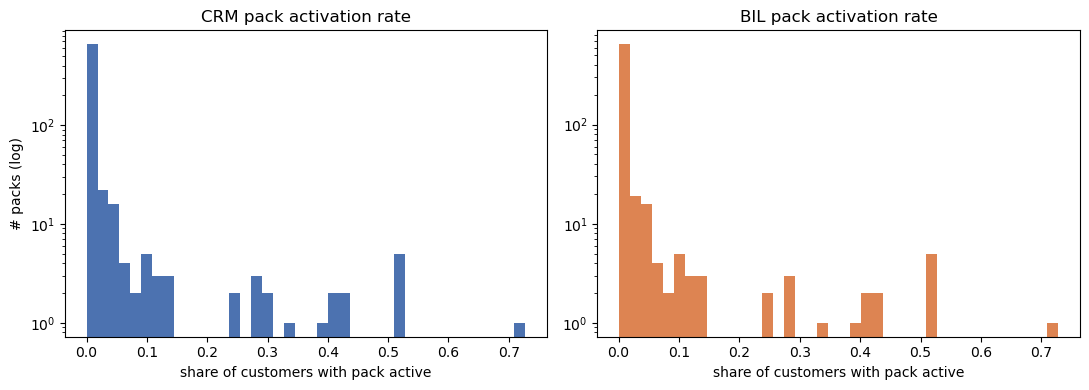

CRM packs active in <0.1% of rows: 16 / 730
BIL packs active in <0.1% of rows: 10 / 717


In [21]:
crm_rate = train[crm_packs].mean().sort_values(ascending=False)
bil_rate = train[bil_packs].mean().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(crm_rate, bins=40, color='#4C72B0')
axes[0].set_title('CRM pack activation rate')
axes[0].set_xlabel('share of customers with pack active')
axes[0].set_ylabel('# packs (log)')
axes[0].set_yscale('log')
axes[1].hist(bil_rate, bins=40, color='#DD8452')
axes[1].set_title('BIL pack activation rate')
axes[1].set_xlabel('share of customers with pack active')
axes[1].set_yscale('log')
plt.tight_layout()
plt.show()

print('CRM packs active in <0.1% of rows:', int((crm_rate < 0.001).sum()), '/', len(crm_rate))
print('BIL packs active in <0.1% of rows:', int((bil_rate < 0.001).sum()), '/', len(bil_rate))

save(pd.concat([
    crm_rate.rename('activation_rate').rename_axis('pack').reset_index().assign(system='CRM'),
    bil_rate.rename('activation_rate').rename_axis('pack').reset_index().assign(system='BIL'),
]), 'pack_activation_rates.csv');

The paired prevalence table below places the CRM and BIL top-ranked packs side by side.
Read pair by pair, the two rates agree closely at the head of the distribution -- early
evidence of a near one-to-one channel structure between the two systems, which Section 6
confirms with formal association statistics and Section 8b confirms with a controlled
contrast.

This should not be over-read in the tail: hundreds of columns cluster between activation
rates of 0.001 and 0.0014 and would appear to "match" by construction. The relevant
evidence is in the head of the distribution, where prevalence values are distinct.

In [22]:
k = 15
paired = pd.DataFrame({
    'rank': np.arange(1, k + 1),
    'crm_pack': crm_rate.index[:k], 'crm_rate': crm_rate.values[:k],
    'bil_pack': bil_rate.index[:k], 'bil_rate': bil_rate.values[:k],
})
paired['abs_diff'] = (paired['crm_rate'] - paired['bil_rate']).abs()
display(paired.round(6))
print(f'mean |difference| over the top {k} ranks: {paired["abs_diff"].mean():.6f}')
save(paired.round(8), 'paired_top_prevalence.csv');

,rank,crm_pack,crm_rate,bil_pack,bil_rate,abs_diff
0,1,CRM_1537_PACK,0.727409,BIL_3748_PACK,0.727542,0.000133
1,2,CRM_1542_PACK,0.520918,BIL_3933_PACK,0.520897,0.000021
2,3,CRM_1533_PACK,0.520908,BIL_3934_PACK,0.520844,0.000064
3,4,CRM_1529_PACK,0.520033,BIL_3921_PACK,0.520017,0.000016
4,5,CRM_1541_PACK,0.519009,BIL_3927_PACK,0.519057,0.000048
5,6,CRM_1532_PACK,0.514623,BIL_3922_PACK,0.514426,0.000197
6,7,CRM_2076_PACK,0.428463,BIL_3749_PACK,0.428202,0.000261
7,8,CRM_2077_PACK,0.423219,BIL_3750_PACK,0.422792,0.000427
8,9,CRM_2087_PACK,0.417414,BIL_3745_PACK,0.417116,0.000299
9,10,CRM_2088_PACK,0.402098,BIL_3744_PACK,0.401751,0.000347


mean |difference| over the top 15 ranks: 0.002771


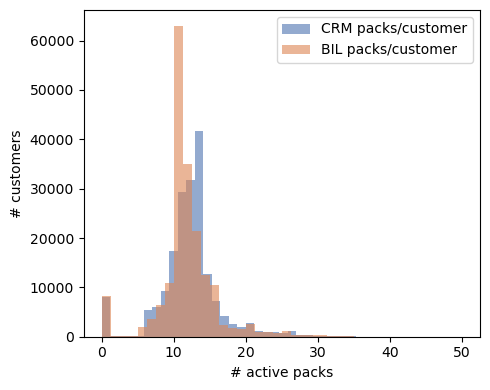

{'count': 187442.0, 'mean': 12.28, 'std': 4.36, 'min': 0.0, '25%': 11.0, '50%': 12.0, '75%': 14.0, 'max': 47.0}
{'count': 187442.0, 'mean': 11.68, 'std': 4.07, 'min': 0.0, '25%': 10.0, '50%': 11.0, '75%': 13.0, 'max': 50.0}

Correlation between #CRM packs and #BIL packs per customer: 0.932


In [23]:
crm_count = train[crm_packs].sum(axis=1)
bil_count = train[bil_packs].sum(axis=1)

fig, ax = plt.subplots(figsize=(5, 4))
ax.hist(crm_count, bins=40, alpha=0.6, label='CRM packs/customer', color='#4C72B0')
ax.hist(bil_count, bins=40, alpha=0.6, label='BIL packs/customer', color='#DD8452')
ax.set_xlabel('# active packs')
ax.set_ylabel('# customers')
ax.legend()
plt.tight_layout()
plt.show()

print(crm_count.describe().round(2).to_dict())
print(bil_count.describe().round(2).to_dict())
print(f'\nCorrelation between #CRM packs and #BIL packs per customer: '
      f'{crm_count.corr(bil_count):.3f}')

The distribution of the *difference* between the CRM and BIL pack counts is more
informative than their correlation, since correlation is scale-free and says nothing about
whether the mapping preserves the number of active items. Concentration of this difference
near zero is consistent with a near one-to-one pack-level correspondence; a broad spread is
not.

Customers with zero active CRM packs are examined separately: if such a customer still
receives billing items, those items cannot originate from any commercial pack, which is
direct evidence that part of the billing configuration is driven by the categorical or
status columns rather than by packs alone.

In [24]:
diff = crm_count - bil_count
print('#CRM packs - #BIL packs :', diff.describe().round(3).to_dict())
print('distribution (top 10)   :', diff.value_counts().sort_index().head(10).to_dict())
print(f'rows where the two counts are EQUAL: {(diff == 0).mean():.2%}')
print(f'rows where |difference| <= 1       : {(diff.abs() <= 1).mean():.2%}')

z = (crm_count == 0).to_numpy()
n_zero = int(z.sum())
print(f'\ncustomers with ZERO CRM packs: {n_zero:,} ({z.mean():.3%})')
zero_billed = int((bil_count[z] > 0).sum()) if n_zero else 0
if n_zero:
    print(f'  their mean BIL pack count             : {bil_count[z].mean():.2f}')
    print(f'  how many still receive >=1 BIL pack   : {zero_billed:,}')
    print(f'  distinct BIL configurations among them: {pd.Series(bil_code[z]).nunique():,}')

save(pd.DataFrame({
    'crm_packs_per_customer': crm_count.describe(),
    'bil_packs_per_customer': bil_count.describe(),
    'crm_minus_bil_packs': diff.describe(),
}).assign(
    crm_bil_pack_count_corr=round(float(crm_count.corr(bil_count)), 6),
    pct_rows_counts_equal=round(float((diff == 0).mean()), 6),
    pct_rows_count_diff_le_1=round(float((diff.abs() <= 1).mean()), 6),
    n_customers_zero_crm_packs=n_zero,
    n_zero_pack_customers_still_billed=zero_billed,
), 'pack_count_stats.csv', index=True);

#CRM packs - #BIL packs : {'count': 187442.0, 'mean': 0.607, 'std': 1.575, 'min': -18.0, '25%': 0.0, '50%': 0.0, '75%': 2.0, 'max': 24.0}
distribution (top 10)   : {-18: 4, -17: 1, -16: 5, -15: 7, -14: 8, -13: 16, -12: 27, -11: 41, -10: 68, -9: 118}
rows where the two counts are EQUAL: 63.48%
rows where |difference| <= 1       : 66.49%

customers with ZERO CRM packs: 1 (0.001%)
  their mean BIL pack count             : 1.00
  how many still receive >=1 BIL pack   : 1
  distinct BIL configurations among them: 1


## 5b. Pack-count outliers (IQR)

`crm_count` and `bil_count` are right-skewed and long-tailed, so Tukey's IQR fences are
used in preference to z-scores, which assume approximate symmetry and would over-flag the
tail of a skewed distribution using a mean and standard deviation that the tail itself
distorts.

Flagged rows are not removed or capped. A customer with an unusual pack count is not a
measurement error; they are a real row that still requires a correct prediction in test,
and removing or capping such rows would strip exactly the hardest cases from training
without evidence that anything about them is incorrect. An IQR fence on a bounded count
with a median near 12 flags a non-trivial share of rows by construction, since it is
simply marking the tail of a skewed distribution rather than identifying an anomaly; the
fence is therefore paired with a measured consequence per pack-count band -- ambiguity
rate, billing complexity, configuration diversity -- to establish who the flagged
customers actually are.

In [25]:
crm_is_outlier, crm_lo, crm_hi = flag_count_outliers(crm_count)
bil_is_outlier, bil_lo, bil_hi = flag_count_outliers(bil_count)
outlier_mask = crm_is_outlier | bil_is_outlier

print(f'CRM pack-count IQR fences: [{crm_lo:.1f}, {crm_hi:.1f}] -> {int(crm_is_outlier.sum()):,} flagged')
print(f'BIL pack-count IQR fences: [{bil_lo:.1f}, {bil_hi:.1f}] -> {int(bil_is_outlier.sum()):,} flagged')
print(f'Union: {int(outlier_mask.sum()):,} / {len(train):,} rows ({outlier_mask.mean():.2%})')

pack_count_outliers = pd.DataFrame({
    'MSISDN': train.loc[outlier_mask, 'MSISDN'],
    'n_crm_packs': crm_count[outlier_mask],
    'n_bil_packs': bil_count[outlier_mask],
    'crm_outlier': crm_is_outlier[outlier_mask],
    'bil_outlier': bil_is_outlier[outlier_mask],
})
display(pack_count_outliers.head())
save(pack_count_outliers, 'pack_count_outliers.csv');

CRM pack-count IQR fences: [6.5, 18.5] -> 21,673 flagged
BIL pack-count IQR fences: [5.5, 17.5] -> 19,928 flagged
Union: 24,253 / 187,442 rows (12.94%)


,MSISDN,n_crm_packs,n_bil_packs,crm_outlier,bil_outlier
3,a543952f2405c440fc40f85e8adfdfd6,22,14,True,False
21,3bd71759181041e39304827d67870716,24,16,True,False
36,b447a2ae3036f1f4d8a45077a8c2264a,15,26,False,True
46,b07244a41b129847a8ef6265f531685d,17,18,False,True
100,da98d61522e313f8339c88e8e19abeb3,31,17,True,False


In [26]:
is_amb = (nuniq > 1).reindex(pairs['crm']).to_numpy()
bucket = pd.cut(crm_count, [-1, 6, 12, 18, np.inf], labels=['0-6', '7-12', '13-18', '19+'])

ev = pd.DataFrame({'bucket': bucket, 'n_bil': bil_count.to_numpy(), 'ambiguous': is_amb,
                   'cfg': crm_code, 'iqr_flagged': outlier_mask.to_numpy()})
band = ev.groupby('bucket', observed=True).agg(
    rows=('n_bil', 'size'),
    share_of_rows=('n_bil', lambda s: len(s) / len(ev)),
    mean_bil_packs=('n_bil', 'mean'),
    ambiguity_rate=('ambiguous', 'mean'),
    distinct_configs=('cfg', 'nunique'),
    iqr_flagged_share=('iqr_flagged', 'mean'),
).round(4)
display(band)
print('Read: if ambiguity_rate and distinct_configs rise sharply with pack count, the')
print('      high-count band is a genuinely harder population — worth monitoring separately')
print('      in Sprint 2 rather than deleting.')
save(band.reset_index(), 'pack_count_bands.csv');

,rows,share_of_rows,mean_bil_packs,ambiguity_rate,distinct_configs,iqr_flagged_share
bucket,,,,,,
0-6,10380,0.0554,2.0239,0.9177,513,1.0000
7-12,97323,0.5192,10.4270,0.4354,17190,0.0019
13-18,68446,0.3652,13.3309,0.0949,38498,0.0350
19+,11293,0.0602,21.3018,0.0003,11233,1.0000


Read: if ambiguity_rate and distinct_configs rise sharply with pack count, the
      high-count band is a genuinely harder population — worth monitoring separately
      in Sprint 2 rather than deleting.


## 5c. Label imbalance check

Column activation rates are bucketed from ultra-rare to dense. This matters specifically
because the evaluation metric is EMR: a classifier that predicts all-zero for a rare BIL
pack still scores well under a per-label metric, but under EMR that single wrong bit fails
the entire row regardless of how well the rest of the row is predicted. The quantity that
actually bounds EMR is not the count of rare *columns* but the share of *rows* containing
at least one rare positive -- exactly the fraction an all-zero-on-the-tail predictor would
fail.

In [27]:
crm_imbalance = label_imbalance_report(train[crm_cols].mean())
bil_imbalance = label_imbalance_report(train[bil_cols].mean())
print('CRM columns:')
display(crm_imbalance)
print('\nBIL columns (the actual prediction targets):')
display(bil_imbalance)

save(pd.concat([crm_imbalance.assign(system='CRM'), bil_imbalance.assign(system='BIL')]),
     'label_imbalance.csv');

CRM columns:


,imbalance_tier,n_columns
0,ultra_rare(<0.1%),16
1,rare(0.1-1%),613
2,uncommon(1-10%),82
3,common(10-50%),25
4,dense(>=50%),9



BIL columns (the actual prediction targets):


,imbalance_tier,n_columns
0,ultra_rare(<0.1%),10
1,rare(0.1-1%),607
2,uncommon(1-10%),82
3,common(10-50%),23
4,dense(>=50%),9


In [28]:
rows_ = []
for thr, name in [(0.001, 'ultra-rare (<0.1%)'), (0.01, 'rare (<1%)'),
                  (0.10, 'uncommon (<10%)')]:
    idx = np.flatnonzero(bil_rate_all.to_numpy() < thr)
    has = Yc[:, idx].sum(1) > 0
    print(f'{name:<22} {len(idx):>3} BIL columns | rows holding >=1 such positive: '
          f'{has.mean():>7.2%} -> EMR ceiling if all predicted 0: {1 - has.mean():.4f}')
    rows_.append({'tier': name, 'threshold': thr, 'n_bil_columns': int(len(idx)),
                  'pct_rows_with_at_least_one_positive': round(float(has.mean()), 6),
                  'emr_ceiling_if_predicted_all_zero': round(float(1 - has.mean()), 6)})
save(pd.DataFrame(rows_), 'rare_label_row_coverage.csv');

ultra-rare (<0.1%)      10 BIL columns | rows holding >=1 such positive:   0.92% -> EMR ceiling if all predicted 0: 0.9908
rare (<1%)             617 BIL columns | rows holding >=1 such positive:  38.35% -> EMR ceiling if all predicted 0: 0.6165
uncommon (<10%)        699 BIL columns | rows holding >=1 such positive:  93.99% -> EMR ceiling if all predicted 0: 0.0601


## 6. Association structure between CRM and Billing

The association matrices in this section are computed on the full 187,442-row training
set via the chunked co-occurrence helper defined in Section 0, rather than on a subsample:
a column with prevalence 0.001 has roughly 30 positive rows in a 30,000-row sample, which
is too few for its estimated association to be reliable, and those rare columns are
precisely the ones later sections identify as the hardest to predict.

Two association statistics are reported in addition to Jaccard similarity, because Pearson
correlation (or its binary analogue, phi) is symmetric, and the brief's central structural
claim -- many CRM configurations mapping to one billing configuration -- is directional.
`P(BIL_k | CRM_j)` identifies a *trigger*: how often activating a CRM pack is accompanied
by a given billing item. `P(CRM_j | BIL_k)` identifies a *necessary condition*: how often a
billing item is accompanied by a given CRM pack. Jaccard similarity is used for the pairing
question specifically because, unlike phi, it is not distorted by the difference in
prevalence between a common and a rare column.

In [29]:
Xp = train[crm_packs].to_numpy(np.uint8)
Yp = train[bil_packs].to_numpy(np.uint8)

n11 = cooc(Xp, Yp)                                    # full data, chunked
nx_ = Xp.sum(0).astype(float)
ny_ = Yp.sum(0).astype(float)

conf_fwd = n11 / np.maximum(nx_[:, None], 1)          # P(BIL_k | CRM_j)  -- trigger
conf_rev = n11 / np.maximum(ny_[None, :], 1)          # P(CRM_j | BIL_k)  -- necessary condition
jac = n11 / np.maximum(nx_[:, None] + ny_[None, :] - n11, 1)

# within-family co-occurrence, computed ONCE here and reused by 6b and 7c (the previous
# version recomputed these in separate cells).
Cxx = cooc(Xp, Xp)
Jxx = Cxx / np.maximum(nx_[:, None] + nx_[None, :] - Cxx, 1)
np.fill_diagonal(Jxx, 0.0)
Cyy = cooc(Yp, Yp)
Jyy = Cyy / np.maximum(ny_[:, None] + ny_[None, :] - Cyy, 1)
np.fill_diagonal(Jyy, 0.0)

print('association matrices:', n11.shape, f'(computed on all {len(Xp):,} rows)')
print('within-family matrices:', Jxx.shape, Jyy.shape)

association matrices: (730, 717) (computed on all 187,442 rows)
within-family matrices: (730, 730) (717, 717)


Read together, the confidence and Jaccard statistics surface the central structural
observation of this dataset: several CRM packs that are themselves highly correlated with
one another (bundled in the sense of always being sold together) each drive a *different*
billing item at approximately 0.99 confidence in both directions. Being bundled together
is not the same as being interchangeable, a distinction that matters directly for any
deduplication decision made in Section 10.

In [30]:
bidx = np.arange(len(bil_packs))
best = jac.argmax(0)
channels = pd.DataFrame({
    'bil_pack': bil_packs,
    'best_crm_pack': [crm_packs[j] for j in best],
    'jaccard': jac.max(0),
    'conf_fwd_P_bil_given_crm': conf_fwd[best, bidx],
    'conf_rev_P_crm_given_bil': conf_rev[best, bidx],
    'bil_prevalence': ny_ / len(Yp),
}).round(6)

print('Top 20 CRM -> BIL channels (near one-to-one in both directions):')
display(channels.sort_values('jaccard', ascending=False).head(20))
print('\nTop 20 HARDEST BIL packs (weakest best partner):')
display(channels.sort_values('jaccard').head(20))
save(channels.sort_values('jaccard', ascending=False), 'crm_bil_channels.csv');

Top 20 CRM -> BIL channels (near one-to-one in both directions):


,bil_pack,best_crm_pack,jaccard,conf_fwd_P_bil_given_crm,conf_rev_P_crm_given_bil,bil_prevalence
9,BIL_3748_PACK,CRM_1537_PACK,0.996333,0.998254,0.998071,0.727542
85,BIL_3934_PACK,CRM_1533_PACK,0.995973,0.997921,0.998044,0.520844
84,BIL_3933_PACK,CRM_1533_PACK,0.995891,0.997931,0.997952,0.520897
78,BIL_3927_PACK,CRM_1541_PACK,0.995702,0.997893,0.997800,0.519057
72,BIL_3921_PACK,CRM_1529_PACK,0.995506,0.997733,0.997763,0.520017
73,BIL_3922_PACK,CRM_1532_PACK,0.995397,0.997502,0.997884,0.514426
7,BIL_3745_PACK,CRM_2087_PACK,0.994238,0.996754,0.997468,0.417116
6,BIL_3744_PACK,CRM_2088_PACK,0.994163,0.996643,0.997503,0.401751
86,BIL_3935_PACK,CRM_1538_PACK,0.994121,0.996867,0.997237,0.388083
10,BIL_3749_PACK,CRM_2076_PACK,0.994052,0.996713,0.997321,0.428202



Top 20 HARDEST BIL packs (weakest best partner):


,bil_pack,best_crm_pack,jaccard,conf_fwd_P_bil_given_crm,conf_rev_P_crm_given_bil,bil_prevalence
617,BIL_4355_PACK,CRM_2297_PACK,0.017199,0.033175,0.034483,0.001083
622,BIL_4360_PACK,CRM_1962_PACK,0.017677,0.031963,0.038043,0.000982
676,BIL_4431_PACK,CRM_2370_PACK,0.017857,0.034934,0.035242,0.001211
237,BIL_3856_PACK,CRM_2371_PACK,0.017949,0.034314,0.036269,0.001030
565,BIL_4342_PACK,CRM_2183_PACK,0.018088,0.034653,0.036458,0.001024
534,BIL_4294_PACK,CRM_2065_PACK,0.018100,0.034483,0.036697,0.001163
397,BIL_3818_PACK,CRM_1909_PACK,0.018182,0.034483,0.037037,0.001152
701,BIL_4459_PACK,CRM_1717_PACK,0.018182,0.034783,0.036697,0.001163
434,BIL_3906_PACK,CRM_1782_PACK,0.018229,0.035354,0.036269,0.001030
276,BIL_4030_PACK,CRM_1890_PACK,0.018307,0.033755,0.038462,0.001110


best Jaccard per BIL pack, quantiles (0,.05,.25,.5,.75,.95,1): [0.0172 0.0194 0.0234 0.0994 0.5377 0.9539 0.9963]
  t=0.99 | best Jaccard >= t:   16 | has trigger P(BIL|CRM) >= t:   32 | has necessary cond. P(CRM|BIL) >= t:   33
  t=0.95 | best Jaccard >= t:   41 | has trigger P(BIL|CRM) >= t:   69 | has necessary cond. P(CRM|BIL) >= t:  103
  t=0.90 | best Jaccard >= t:   63 | has trigger P(BIL|CRM) >= t:  106 | has necessary cond. P(CRM|BIL) >= t:  154
  t=0.50 | best Jaccard >= t:  195 | has trigger P(BIL|CRM) >= t:  238 | has necessary cond. P(CRM|BIL) >= t:  717
  t=0.30 | best Jaccard >= t:  249 | has trigger P(BIL|CRM) >= t:  314 | has necessary cond. P(CRM|BIL) >= t:  717


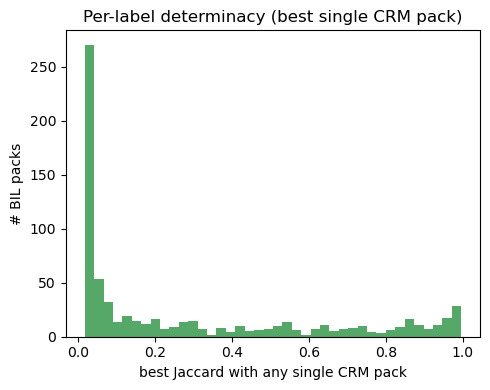

In [31]:
print('best Jaccard per BIL pack, quantiles (0,.05,.25,.5,.75,.95,1):',
      np.round(np.quantile(jac.max(0), [0, .05, .25, .5, .75, .95, 1]), 4))

thr_rows = []
for t in [0.99, 0.95, 0.90, 0.50, 0.30]:
    a = int((jac.max(0) >= t).sum())
    b = int((conf_fwd.max(0) >= t).sum())
    c = int((conf_rev.max(0) >= t).sum())
    print(f'  t={t:.2f} | best Jaccard >= t: {a:>4} | has trigger P(BIL|CRM) >= t: {b:>4} '
          f'| has necessary cond. P(CRM|BIL) >= t: {c:>4}')
    thr_rows.append({'threshold': t, 'n_bil_with_jaccard_ge_t': a,
                     'n_bil_with_trigger_ge_t': b, 'n_bil_with_necessary_cond_ge_t': c})
save(pd.DataFrame(thr_rows), 'association_thresholds.csv')

plt.figure(figsize=(5, 4))
plt.hist(jac.max(0), bins=40, color='#55A868')
plt.xlabel('best Jaccard with any single CRM pack')
plt.ylabel('# BIL packs')
plt.title('Per-label determinacy (best single CRM pack)')
plt.tight_layout()
plt.show()

save(pd.DataFrame({'bil_pack': bil_packs,
                   'best_jaccard': jac.max(0).round(6),
                   'best_conf_fwd': conf_fwd.max(0).round(6),
                   'best_conf_rev': conf_rev.max(0).round(6)}),
     'bil_predictability.csv');

## 6b. Exact duplicate columns

Any correlation-threshold-based deduplication implicitly assumes that a correlation of,
say, 0.99 is close enough to 1.00 to treat two columns as the same. For prediction targets
evaluated under EMR this assumption does not hold: two columns correlated at 0.996 can
still disagree on hundreds of rows, and each such disagreement fails a whole row.

Column hashing answers the question exactly, without a threshold: which columns are
*literally identical* across all 187,442 rows. Only columns satisfying this exact criterion
are safe to collapse without any loss of information, and only on the feature side --
never among the 731 prediction targets, every one of which must be emitted in a final
submission.

In [32]:
dup_rows = []
for name, cols, M in [('CRM', crm_cols, Xc), ('BIL', bil_cols, Yc)]:
    d = defaultdict(list)
    for c, kk in zip(cols, col_keys(M)):
        d[kk].append(c)
    dup = [v for v in d.values() if len(v) > 1]
    print(f'{name}: {len(dup)} groups of EXACTLY identical columns')
    for g_ in dup:
        print('   ', g_)
        dup_rows.append({'system': name, 'n_columns': len(g_), 'columns': ';'.join(g_)})
save(pd.DataFrame(dup_rows) if dup_rows else pd.DataFrame(
    [{'system': None, 'n_columns': 0, 'columns': None}]), 'exact_duplicate_columns.csv')

print('\nTop near-duplicate BIL pairs by Jaccard, with their TRUE row disagreement:')
iu = np.triu_indices(len(bil_packs), k=1)
ordr = np.argsort(-Jyy[iu])[:15]
near_rows = []
for t in ordr:
    a, b = int(iu[0][t]), int(iu[1][t])
    disagree = float((Yp[:, a] != Yp[:, b]).mean())
    print(f'  {bil_packs[a]:>16} / {bil_packs[b]:>16}  jaccard={Jyy[a, b]:.4f}  '
          f'rows differing={disagree:.4%}')
    near_rows.append({'col_a': bil_packs[a], 'col_b': bil_packs[b],
                      'jaccard': round(float(Jyy[a, b]), 6),
                      'pct_rows_differing': round(disagree, 8)})
save(pd.DataFrame(near_rows), 'near_duplicate_bil_pairs.csv')
print('\n-> collapsing any of these would hard-cap EMR at roughly the product of')
print('   (1 - pct_rows_differing) across the collapsed pairs. Keep all 731 targets.')

# The CRM counterpart: each member of a near-duplicate CRM pair is shown with the BIL pack
# it drives, which is the direct evidence that bundled is not interchangeable.
print('\nTop near-duplicate CRM pairs, each member with the BIL pack it drives:')
iu_x = np.triu_indices(len(crm_packs), k=1)
ordr_x = np.argsort(-Jxx[iu_x])[:15]
crm_near = []
for t in ordr_x:
    a, b = int(iu_x[0][t]), int(iu_x[1][t])
    ba, bb = int(jac[a].argmax()), int(jac[b].argmax())
    print(f'  {crm_packs[a]:>16} / {crm_packs[b]:>16}  jaccard={Jxx[a, b]:.4f}  '
          f'| drives {bil_packs[ba]:>16} vs {bil_packs[bb]:>16}  '
          f"{'SAME' if ba == bb else 'DIFFERENT'}")
    crm_near.append({'col_a': crm_packs[a], 'col_b': crm_packs[b],
                     'jaccard': round(float(Jxx[a, b]), 6),
                     'pct_rows_differing': round(float((Xp[:, a] != Xp[:, b]).mean()), 8),
                     'best_bil_for_a': bil_packs[ba], 'best_bil_for_b': bil_packs[bb],
                     'drives_same_bil_pack': bool(ba == bb)})
save(pd.DataFrame(crm_near), 'near_duplicate_crm_pairs.csv')
print('\n-> where drives_same_bil_pack is False, the two CRM packs are bundled but NOT')
print('   redundant: collapsing them would destroy a distinct trigger.')

CRM: 1 groups of EXACTLY identical columns
    ['CRM_2396_PACK', 'CRM_2398_PACK']
BIL: 0 groups of EXACTLY identical columns

Top near-duplicate BIL pairs by Jaccard, with their TRUE row disagreement:
     BIL_3933_PACK /    BIL_3934_PACK  jaccard=0.9959  rows differing=0.2145%
     BIL_3921_PACK /    BIL_3934_PACK  jaccard=0.9940  rows differing=0.3132%
     BIL_3921_PACK /    BIL_3933_PACK  jaccard=0.9939  rows differing=0.3164%
     BIL_3927_PACK /    BIL_3934_PACK  jaccard=0.9922  rows differing=0.4071%
     BIL_3927_PACK /    BIL_3933_PACK  jaccard=0.9922  rows differing=0.4081%
     BIL_3921_PACK /    BIL_3927_PACK  jaccard=0.9907  rows differing=0.4866%
     BIL_3922_PACK /    BIL_3934_PACK  jaccard=0.9833  rows differing=0.8712%
     BIL_3922_PACK /    BIL_3933_PACK  jaccard=0.9833  rows differing=0.8733%
     BIL_3921_PACK /    BIL_3922_PACK  jaccard=0.9813  rows differing=0.9763%
     BIL_3922_PACK /    BIL_3927_PACK  jaccard=0.9795  rows differing=1.0681%
     BIL_3749_PACK 

## 7. Structure discovery

A linear, variance-maximising decomposition is not an appropriate tool for this feature
space, for reasons established with evidence in Section 7a: variance in sparse binary data
is dominated by a small number of dense columns, and an uncentred decomposition such as
`TruncatedSVD` tracks row norm (that is, pack count) rather than any latent commercial
structure. Sections 7b-7d instead target the two objects where structure is actually
expected to live -- the pack co-occurrence graph and the CRM-to-Billing association matrix
-- rather than the customer population, and Section 7d validates any customer-level
clustering with a silhouette score instead of asserting a cluster count.

### 7a. Why PCA / truncated SVD is not used for structure discovery

For a Bernoulli column, variance is $p(1-p)$. With a median CRM pack prevalence near 0.0014, a dense column at $p \approx 0.52$ carries roughly 180 times the variance of a typical rare one. Since PCA maximises explained variance, its leading components are determined almost entirely by the handful of dense packs, and the rare packs -- where the modelling difficulty concentrates -- are effectively invisible to them.

Centred PCA and the uncentred `TruncatedSVD` used in an earlier iteration of this analysis are both evaluated empirically against pack count, since the two estimators are not interchangeable: `TruncatedSVD` does not centre the data, and its leading singular vector can therefore track row norm rather than any latent structure.

> **Methodological Note:**  
> There is a crucial epistemological distinction between using TruncatedSVD for **unsupervised structure discovery / clustering** (which is rightfully rejected here because the leading component merely tracks customer size / pack density) versus using it for **supervised hybrid feature representation** (as introduced later in Section 11.5). In feature engineering, capturing the dense global volume/intensity of a customer as a continuous coordinate provides valuable inductive bias to gradient boosting trees, provided it *supplements* rather than *replaces* the sparse binary pack indicators.


In [33]:
p = Xp.mean(0)
v = p * (1 - p)
o = np.sort(v)[::-1]
conc = []
print('Variance concentration across the CRM pack columns:')
for k_ in [5, 10, 20, 50, 100]:
    share = float(o[:k_].sum() / v.sum())
    print(f'  top {k_:>3} columns hold {share:6.1%} of total variance')
    conc.append({'top_k_columns': k_, 'share_of_total_variance': round(share, 6)})
n90 = int((np.cumsum(o) / v.sum() < 0.90).sum()) + 1
print(f'  columns needed for 90% of variance: {n90} of {len(o)}')

from sklearn.decomposition import PCA
sub_idx = RNG.choice(len(Xp), min(30000, len(Xp)), replace=False)
sub = Xp[sub_idx].astype(np.float32)
pca = PCA(n_components=5, random_state=0).fit(sub)
Z = pca.transform(sub)
npacks = sub.sum(1)
print(f'\nexplained variance of 5 PCs: {pca.explained_variance_ratio_.sum():.1%}')
pc_rows = []
for i in range(3):
    c_ = float(np.corrcoef(Z[:, i], npacks)[0, 1])
    print(f'  corr(PC{i+1}, #packs per customer) = {c_:+.3f}')
    pc_rows.append({'component': f'PC{i+1}', 'corr_with_pack_count': round(c_, 6)})
# sklearn's PCA centres the data; TruncatedSVD does not. Since these are not
# interchangeable estimators, both are reported rather than only the centred one.
from sklearn.decomposition import TruncatedSVD
svd_u = TruncatedSVD(n_components=5, random_state=0).fit(sub)
Zu = svd_u.transform(sub)
print('\nuncentred TruncatedSVD:')
for i in range(3):
    cu = float(np.corrcoef(Zu[:, i], npacks)[0, 1])
    print(f'  corr(SV{i+1}, #packs per customer) = {cu:+.3f}')
    pc_rows.append({'component': f'SV{i+1} (uncentred)', 'corr_with_pack_count': round(cu, 6)})

print('\nConclusion: the variance argument stands on its own — a handful of dense columns')
print('            carry most of the variance, so the rare packs that drive the modelling')
print('            difficulty are invisible to any variance-maximising projection. Whether')
print('            component 1 is literally a pack-count proxy depends on centring: compare')
print('            the two blocks above. Either way, linear dimensionality reduction is')
print('            inappropriate for a sparse binary, set-valued feature space; the')
print('            appropriate decomposition is Boolean (see 8b).')

save(pd.DataFrame(conc).assign(n_columns_for_90pct_variance=n90,
                               explained_variance_5pc=round(float(pca.explained_variance_ratio_.sum()), 6)),
     'pca_variance_concentration.csv')
save(pd.DataFrame(pc_rows), 'pca_component_vs_pack_count.csv');

Variance concentration across the CRM pack columns:
  top   5 columns hold  14.4% of total variance
  top  10 columns hold  28.4% of total variance
  top  20 columns hold  50.7% of total variance
  top  50 columns hold  73.7% of total variance
  top 100 columns hold  84.9% of total variance
  columns needed for 90% of variance: 166 of 730

explained variance of 5 PCs: 51.0%
  corr(PC1, #packs per customer) = +0.344
  corr(PC2, #packs per customer) = +0.309
  corr(PC3, #packs per customer) = +0.072

uncentred TruncatedSVD:
  corr(SV1, #packs per customer) = +0.561
  corr(SV2, #packs per customer) = -0.237
  corr(SV3, #packs per customer) = +0.085

Conclusion: the variance argument stands on its own — a handful of dense columns
            carry most of the variance, so the rare packs that drive the modelling
            difficulty are invisible to any variance-maximising projection. Whether
            component 1 is literally a pack-count proxy depends on centring: compare
            

### 7b. Co-clustering the CRM x Billing association

Co-clustering groups the two column families jointly, so that blocks of (commercial offer,
billing component) pairs emerge directly, which recovers catalogue structure rather than
customer segments. The association matrix is small, so this is computationally cheap.

The validity measure is fixed in advance: the share of strong pairs (Jaccard above 0.5)
that fall inside a discovered block. A small number of blocks capturing most strong pairs
would indicate real catalogue block structure; a low capture rate is itself a reportable
result.

In [34]:
from sklearn.cluster import SpectralCoclustering

keep_r, keep_c = jac.sum(1) > 0, jac.sum(0) > 0
Jk = jac[np.ix_(keep_r, keep_c)]
print(f'co-clustering a {Jk.shape[0]} x {Jk.shape[1]} Jaccard matrix')

strong = Jk > 0.5
co_rows = []
for k_ in [6, 10, 15, 25, 40]:
    try:
        mdl = SpectralCoclustering(n_clusters=k_, random_state=0, svd_method='arpack').fit(Jk)
    except Exception as e:
        print(f'k={k_}: {type(e).__name__}')
        continue
    inside = np.zeros_like(Jk, bool)
    for b in range(k_):
        r, c = mdl.get_indices(b)
        if len(r) and len(c):
            inside[np.ix_(r, c)] = True
    co_rows.append({'k': k_,
                    'strong_pairs_inside': int((strong & inside).sum()),
                    'strong_pairs_total': int(strong.sum()),
                    'captured': round(float((strong & inside).sum() / max(strong.sum(), 1)), 4),
                    'mean_jaccard_inside': round(float(Jk[inside].mean()), 6) if inside.any() else np.nan,
                    'mean_jaccard_outside': round(float(Jk[~inside].mean()), 6)})
co_df = pd.DataFrame(co_rows)
display(co_df)
save(co_df, 'coclustering_quality.csv');

co-clustering a 728 x 717 Jaccard matrix


c:\Users\D0mTu\miniconda3\envs\L_py_R\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)


,k,strong_pairs_inside,strong_pairs_total,captured,mean_jaccard_inside,mean_jaccard_outside
0,6,386,390,0.9897,0.007386,0.003084
1,10,388,390,0.9949,0.007441,0.003152
2,15,382,390,0.9795,0.007880,0.003451
3,25,366,390,0.9385,0.007816,0.003712
4,40,334,390,0.8564,0.008330,0.004041


### 7c. Bundles as communities in the pack co-occurrence graph

For identifying which packs travel together, community detection on the pack graph is
preferred over hierarchical clustering of a dense correlation matrix: it operates on a
sparse weighted graph, uses a similarity measure appropriate to presence/absence data,
selects its own number of communities rather than requiring one to be fixed in advance, and
comes with modularity as a built-in validity measure. A modularity above roughly 0.3 is
generally taken to indicate genuine community structure; a low value would itself be a
finding, namely that packs do not form clean bundles.

In [35]:
import networkx as nx

# Jxx computed once in 6 and reused here.
comm_rows = []
for thr in [0.2, 0.3, 0.5]:
    W = np.where(Jxx >= thr, Jxx, 0.0)
    G = nx.from_numpy_array(W)
    G.remove_nodes_from(list(nx.isolates(G)))
    if G.number_of_nodes() == 0:
        print(f'thr={thr}: graph empty')
        continue
    comm = nx.community.louvain_communities(G, seed=0)
    q = nx.community.modularity(G, comm)
    print(f'thr={thr}  nodes={G.number_of_nodes():>4}  edges={G.number_of_edges():>6}  '
          f'communities={len(comm):>3}  modularity={q:.3f}  '
          f'sizes={sorted(map(len, comm), reverse=True)[:8]}')
    comm_rows.append({'jaccard_threshold': thr, 'n_nodes': G.number_of_nodes(),
                      'n_edges': G.number_of_edges(), 'n_communities': len(comm),
                      'modularity': round(float(q), 6)})
save(pd.DataFrame(comm_rows), 'pack_community_quality.csv')

W = np.where(Jxx >= 0.3, Jxx, 0.0)
G = nx.from_numpy_array(W)
G.remove_nodes_from(list(nx.isolates(G)))
comm = sorted(nx.community.louvain_communities(G, seed=0), key=len, reverse=True)
print('\nlargest bundles (threshold 0.3):')
memb = []
for ci, c in enumerate(comm):
    for i in sorted(c):
        memb.append({'community': ci, 'crm_pack': crm_packs[i],
                     'activation_rate': round(float(p[i]), 8)})
for c in comm[:5]:
    print('  ', [crm_packs[i] for i in sorted(c)][:12])
save(pd.DataFrame(memb), 'pack_communities.csv');

thr=0.2  nodes= 158  edges=   331  communities= 43  modularity=0.798  sizes=[17, 12, 11, 9, 7, 6, 6, 6]
thr=0.3  nodes= 116  edges=   200  communities= 31  modularity=0.826  sizes=[12, 11, 7, 7, 6, 6, 6, 5]
thr=0.5  nodes=  61  edges=   104  communities= 18  modularity=0.806  sizes=[9, 8, 5, 4, 4, 4, 4, 3]

largest bundles (threshold 0.3):
   ['CRM_1527_PACK', 'CRM_1529_PACK', 'CRM_1532_PACK', 'CRM_1533_PACK', 'CRM_1536_PACK', 'CRM_1537_PACK', 'CRM_1538_PACK', 'CRM_1539_PACK', 'CRM_1541_PACK', 'CRM_1542_PACK', 'CRM_1553_PACK', 'CRM_1594_PACK']
   ['CRM_2076_PACK', 'CRM_2077_PACK', 'CRM_2078_PACK', 'CRM_2079_PACK', 'CRM_2080_PACK', 'CRM_2081_PACK', 'CRM_2087_PACK', 'CRM_2088_PACK', 'CRM_2089_PACK', 'CRM_2091_PACK', 'CRM_2093_PACK']
   ['CRM_1519_PACK', 'CRM_1576_PACK', 'CRM_1577_PACK', 'CRM_1613_PACK', 'CRM_1641_PACK', 'CRM_1675_PACK', 'CRM_1689_PACK']
   ['CRM_1610_PACK', 'CRM_1611_PACK', 'CRM_1633_PACK', 'CRM_1741_PACK', 'CRM_1745_PACK', 'CRM_1754_PACK', 'CRM_1755_PACK']
   ['CRM_1528

### 7d. Customer clustering, validated

Customer-level clustering is performed with three departures from a naive approach: it
clusters *distinct configurations* rather than rows, so that the large share of duplicate
rows does not implicitly weight the result; it uses Jaccard distance, appropriate to
presence/absence data, rather than Euclidean distance on uncentred components; and it
reports a silhouette score across a range of `k` rather than fixing the number of clusters
without validation. A low silhouette across every `k` tested is treated as a legitimate and
informative conclusion in its own right -- that the configuration space is closer to a
continuum than to a set of separable clusters -- rather than as a failure to find the
"correct" `k`.

One diagnostic from cluster profiling is retained: whether a segment's mean pack count is
preserved from CRM to Billing. Segments where the two means coincide are consistent with a
one-to-one pack-level mapping; segments that lose packs are where the mapping is doing
something else.

In [36]:
from scipy.spatial.distance import pdist, squareform
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

U = Xp[first_x.to_numpy()]                      # one row per distinct CRM configuration
print(f'{len(U):,} distinct configurations (vs {len(Xp):,} rows)')

s_idx = RNG.choice(len(U), min(3000, len(U)), replace=False)
S = U[s_idx].astype(bool)
D = squareform(pdist(S, metric='jaccard'))

sil_rows = []
for k_ in [3, 5, 8, 12, 20]:
    lab = AgglomerativeClustering(n_clusters=k_, metric='precomputed',
                                  linkage='average').fit_predict(D)
    sil = float(silhouette_score(D, lab, metric='precomputed'))
    print(f'  k={k_:>3}  silhouette (Jaccard) = {sil:+.3f}  sizes={np.bincount(lab)[:8]}')
    sil_rows.append({'k': k_, 'silhouette_jaccard': round(sil, 6),
                     'largest_cluster_share': round(float(np.bincount(lab).max() / len(lab)), 4)})

# Verdict derived from the measured silhouette rather than a fixed cluster count.
bs = max(sil_rows, key=lambda r: r['silhouette_jaccard'])
v = bs['silhouette_jaccard']
if v < 0.15:
    verdict = 'no meaningful cluster structure — a continuum, not segments'
elif v < 0.35:
    verdict = ('a COARSE split only — moderate separation at the best k, decaying as k grows, '
               'which indicates a few broad groups plus outliers rather than a clean '
               'segmentation that refines')
else:
    verdict = 'genuine cluster structure worth using'
print(f'\nbest k={bs["k"]} at silhouette {v:+.3f}; largest cluster holds '
      f'{bs["largest_cluster_share"]:.1%} of the sample')
print('->', verdict)
save(pd.DataFrame(sil_rows), 'customer_cluster_silhouette.csv');

67,434 distinct configurations (vs 187,442 rows)
  k=  3  silhouette (Jaccard) = +0.306  sizes=[  38  849 2113]
  k=  5  silhouette (Jaccard) = +0.304  sizes=[  36  849 2113    1    1]
  k=  8  silhouette (Jaccard) = +0.298  sizes=[  28  849    4    2    1 2113    2    1]
  k= 12  silhouette (Jaccard) = +0.291  sizes=[  21    3    3    2  848 2113    2    1]
  k= 20  silhouette (Jaccard) = +0.282  sizes=[  2   4   3   2   7 835   2   2]

best k=3 at silhouette +0.306; largest cluster holds 70.4% of the sample
-> a COARSE split only — moderate separation at the best k, decaying as k grows, which indicates a few broad groups plus outliers rather than a clean segmentation that refines


In [37]:
lab_full = AgglomerativeClustering(n_clusters=8, metric='precomputed',
                                   linkage='average').fit_predict(D)
prof = pd.DataFrame({'cluster': lab_full,
                     'n_crm_packs': S.sum(1),
                     'n_bil_packs': Yp[first_x.to_numpy()[s_idx]].sum(1)})
summ = prof.groupby('cluster').agg(size=('cluster', 'size'),
                                   avg_crm_packs=('n_crm_packs', 'mean'),
                                   avg_bil_packs=('n_bil_packs', 'mean')).round(3)
summ['count_preserved'] = (summ['avg_crm_packs'] - summ['avg_bil_packs']).abs() < 0.05
display(summ)
print('Segments where the pack count is preserved are consistent with a one-to-one')
print('pack mapping; those that lose packs are where the mapping is doing something else.')
save(summ.reset_index(), 'customer_segments.csv');

,size,avg_crm_packs,avg_bil_packs,count_preserved
cluster,,,,
0,28,7.821,8.464,False
1,849,14.449,14.378,False
2,4,15.250,9.500,False
3,2,14.500,15.500,False
4,1,22.000,19.000,False
5,2113,15.513,14.404,False
6,2,13.000,8.000,False
7,1,22.000,22.000,True


Segments where the pack count is preserved are consistent with a one-to-one
pack mapping; those that lose packs are where the mapping is doing something else.


## 8. Aggregation by billing configuration (long tail)

If a small number of configurations covered most of the customer base, Sprint 2 could
plausibly be framed, in part, as "classify into a known bundle, handle the long tail
separately." This section answers that question directly with a coverage curve, rather
than posing it and leaving it open.

Top 15 most common BIL configurations:
 rank    share  n_active_labels
    1 0.043331                4
    2 0.014554               14
    3 0.014026               14
    4 0.009166               13
    5 0.007778               14
    6 0.007725               13
    7 0.007208                9
    8 0.006583               13
    9 0.006514               10
   10 0.006274               13
   11 0.004924               12
   12 0.004689               11
   13 0.004364               15
   14 0.003879               14
   15 0.003772               15


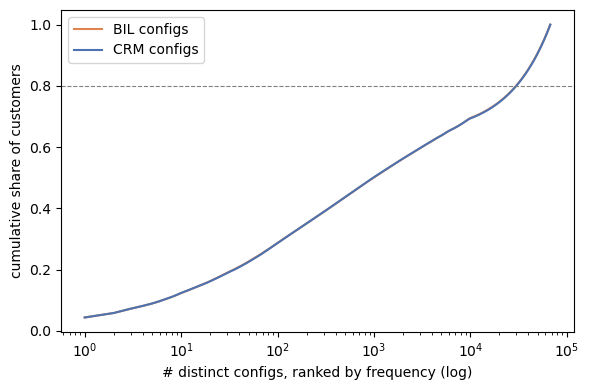

# distinct BIL configs covering 50% of customers: 990 of 67,201
# distinct BIL configs covering 80% of customers: 29,713 of 67,201
# distinct BIL configs covering 90% of customers: 48,457 of 67,201
# distinct BIL configs covering 95% of customers: 57,829 of 67,201

ANSWER (8): no small set of configurations covers the base. A "classify into a known
            bundle" framing is not supported, and 2b independently rules out lookup
            because test configurations are essentially disjoint from train.


In [38]:
bil_counts = pairs['bil'].value_counts()
crm_counts = pairs['crm'].value_counts()

bil_top = (bil_counts.head(15) / len(train)).reset_index()
bil_top.columns = ['bil_config_code', 'share']
bil_top.insert(0, 'rank', range(1, len(bil_top) + 1))
bil_top['n_active_labels'] = [int(Yc[first_y.loc[c]].sum()) for c in bil_top['bil_config_code']]
print('Top 15 most common BIL configurations:')
print(bil_top[['rank', 'share', 'n_active_labels']].to_string(index=False))
save(bil_top[['rank', 'share', 'n_active_labels']], 'bil_top_configs.csv')


def coverage_curve(counts, ax, label, color):
    cum_ = counts.sort_values(ascending=False).cumsum() / counts.sum()
    ax.plot(np.arange(1, len(cum_) + 1), cum_.values, label=label, color=color)


fig, ax = plt.subplots(figsize=(6, 4))
coverage_curve(bil_counts, ax, 'BIL configs', '#DD8452')
coverage_curve(crm_counts, ax, 'CRM configs', '#4C72B0')
ax.set_xscale('log')
ax.set_xlabel('# distinct configs, ranked by frequency (log)')
ax.set_ylabel('cumulative share of customers')
ax.axhline(0.8, color='grey', linestyle='--', linewidth=0.8)
ax.legend()
plt.tight_layout()
plt.show()

cum = bil_counts.sort_values(ascending=False).cumsum() / bil_counts.sum()
cov_rows = []
for f in [0.5, 0.8, 0.9, 0.95]:
    n_ = int((cum < f).sum()) + 1
    print(f'# distinct BIL configs covering {f:.0%} of customers: {n_:,} of {len(bil_counts):,}')
    cov_rows.append({'coverage': f, 'n_bil_configs_needed': n_})
print('\nANSWER (8): no small set of configurations covers the base. A "classify into a known')
print('            bundle" framing is not supported, and 2b independently rules out lookup')
print('            because test configurations are essentially disjoint from train.')
save(pd.DataFrame(cov_rows).assign(n_distinct_bil_configs=int(len(bil_counts)),
                                   n_distinct_crm_configs=int(len(crm_counts))),
     'config_coverage_summary.csv');

In [39]:
segment_cols = [c for c in crm_meta if 'SUBSCRIBER_TYPE' in c or 'BUSINESS_LINE' in c]
seg = train[segment_cols].copy()
seg['n_bil_packs'] = bil_count.to_numpy()
seg['n_crm_packs'] = crm_count.to_numpy()

segment_rows = []
for c in segment_cols:
    mask = seg[c] == 1
    if mask.sum() == 0:
        continue
    avg_crm = seg.loc[mask, 'n_crm_packs'].mean()
    avg_bil = seg.loc[mask, 'n_bil_packs'].mean()
    print(f'{c:45s} n={int(mask.sum()):>7}  prevalence={mask.mean():6.2%}  '
          f'avg CRM packs={avg_crm:5.1f}  avg BIL packs={avg_bil:5.1f}')
    segment_rows.append({'segment': c, 'n_customers': int(mask.sum()),
                         'prevalence': round(float(mask.mean()), 6),
                         'avg_crm_packs': round(float(avg_crm), 3),
                         'avg_bil_packs': round(float(avg_bil), 3),
                         'near_constant_column': bool(mask.mean() > 0.99)})
print('\nTwo readings follow from the table above:')
print('  * a segment with ~99.9% prevalence is near-constant and is NOT a useful feature,')
print('    however strongly billing complexity appears to "track" it;')
print('  * a tiny placeholder-looking category carrying roughly double the pack count of the')
print('    main population is an anomaly worth flagging, not a segment worth modelling.')
save(pd.DataFrame(segment_rows), 'segment_pack_averages.csv');

CRM_BUSINESS_LINE_ORIG_Mobile                 n= 187203  prevalence=99.87%  avg CRM packs= 12.3  avg BIL packs= 11.7
CRM_SUBSCRIBER_TYPE_ORIG_0                    n=    211  prevalence= 0.11%  avg CRM packs= 21.5  avg BIL packs= 20.5
CRM_SUBSCRIBER_TYPE_ORIG_Postpaid             n=  37797  prevalence=20.16%  avg CRM packs= 10.5  avg BIL packs= 10.0
CRM_SUBSCRIBER_TYPE_ORIG_Prepaid              n= 149662  prevalence=79.84%  avg CRM packs= 12.7  avg BIL packs= 12.1

Two readings follow from the table above:
  * a segment with ~99.9% prevalence is near-constant and is NOT a useful feature,
    however strongly billing complexity appears to "track" it;
  * a tiny placeholder-looking category carrying roughly double the pack count of the
    main population is an anomaly worth flagging, not a segment worth modelling.


## 8b. Structural test: is billing additive over packs?

This is the central structural question of the case study, and it is answerable with
pre-processing alone. The pairwise association statistics in Section 6 are confounded: a
pack sold only alongside its real trigger will show a high conditional probability with
that trigger's billing item without itself causing it.

The test implemented here is a matched-pairs contrast: two CRM configurations that differ
in exactly one pack are compared, and the difference between their billing configurations
is attributed to that pack, since every other feature is held fixed by construction. Two
properties of this difference are reported. *Consistency* (the modal share) asks whether
adding a given pack produces the same billing change every time it is observed; weight is
implicitly given to pairs with more supporting evidence, since a pack observed in only one
or two pairs is dominated by sampling noise. *Monotonicity* asks whether adding a pack ever
*removes* a billing item; if it never does, billing is a monotone union over packs, which
is a strong constraint on the class of models appropriate for Sprint 2.

This contrast identifies the *incremental* contribution of a pack, not its total
contribution, and not every pack has a distance-one neighbour in the training data. It is
evidence about the *form* of the mapping, and a comparatively weak basis for constructing
the mapping directly.

In [40]:
cnt_sorted = (pairs.groupby(['crm', 'bil']).size().rename('c').reset_index()
              .sort_values(['crm', 'c'], ascending=[True, False]).drop_duplicates('crm'))
cfg_ids = cnt_sorted['crm'].to_numpy()

Xu = Xc[first_x.loc[cfg_ids].to_numpy()]
Yu = Yc[first_y.loc[cnt_sorted['bil'].to_numpy()].to_numpy()]
print(f'{len(Xu):,} distinct CRM configurations, each with its modal billing configuration')

setsX = [frozenset(np.flatnonzero(r).tolist()) for r in Xu]
setsY = [frozenset(np.flatnonzero(r).tolist()) for r in Yu]
index = {s: i for i, s in enumerate(setsX)}

deltas = defaultdict(list)
for i, s in enumerate(setsX):
    for j in s:
        i2 = index.get(s - {j})
        if i2 is not None:
            deltas[j].append((setsY[i] - setsY[i2], setsY[i2] - setsY[i]))

n_pairs = sum(len(v) for v in deltas.values())
print(f'CRM columns with >=1 distance-1 pair: {len(deltas)} / {len(crm_cols)}')
print(f'total distance-1 configuration pairs: {n_pairs:,}')

67,434 distinct CRM configurations, each with its modal billing configuration
CRM columns with >=1 distance-1 pair: 538 / 745
total distance-1 configuration pairs: 20,997


In [41]:
rows_ = []
for j, v in deltas.items():
    c = Counter(v)
    top_delta, top_n = c.most_common(1)[0]
    rows_.append({'crm_column': crm_cols[j], 'n_pairs': len(v), 'n_distinct_deltas': len(c),
                  'modal_share': round(top_n / len(v), 6),
                  'n_bil_added': len(top_delta[0]), 'n_bil_removed': len(top_delta[1]),
                  'modal_delta_added': ';'.join(sorted(bil_cols[i] for i in top_delta[0])),
                  'modal_delta_removed': ';'.join(sorted(bil_cols[i] for i in top_delta[1]))})
D_ = pd.DataFrame(rows_).sort_values('n_pairs', ascending=False)

print('consistency of the billing delta across distance-1 pairs:')
print(D_['modal_share'].describe().round(3).to_dict())
cons_rows = []
for t in [1.0, 0.99, 0.95, 0.90]:
    m_ = D_['modal_share'] >= t
    print(f'  columns with modal_share >= {t:.2f}: {int(m_.sum()):>4}/{len(D_)}  '
          f'(covering {int(D_.loc[m_, "n_pairs"].sum()):,} of {n_pairs:,} pairs)')
    cons_rows.append({'modal_share_threshold': t, 'n_columns': int(m_.sum()),
                      'n_columns_total': len(D_),
                      'pairs_covered': int(D_.loc[m_, 'n_pairs'].sum()),
                      'pairs_total': int(n_pairs)})

n_monotone = int((D_['n_bil_removed'] == 0).sum())
print('\nmonotonicity — does adding a pack ever REMOVE a billing item?')
print(f'  columns whose modal delta removes nothing: {n_monotone}/{len(D_)}')
print(f'  n_bil_added for the modal delta, quantiles (0,.25,.5,.75,1): '
      f'{np.round(np.quantile(D_["n_bil_added"], [0, .25, .5, .75, 1]), 2)}')
display(D_.head(20))

save(D_, 'additivity_by_pack.csv')
save(pd.DataFrame(cons_rows).assign(
    n_columns_with_distance1_pair=len(deltas),
    n_distance1_pairs=int(n_pairs),
    median_modal_share=round(float(D_['modal_share'].median()), 6),
    n_columns_modal_delta_removes_nothing=n_monotone,
    median_n_bil_added=float(np.median(D_['n_bil_added'])),
), 'additivity_summary.csv');

consistency of the billing delta across distance-1 pairs:
{'count': 538.0, 'mean': 0.864, 'std': 0.213, 'min': 0.25, '25%': 0.753, '50%': 0.997, '75%': 1.0, 'max': 1.0}
  columns with modal_share >= 1.00:  268/538  (covering 1,220 of 20,997 pairs)
  columns with modal_share >= 0.99:  279/538  (covering 4,230 of 20,997 pairs)
  columns with modal_share >= 0.95:  352/538  (covering 18,805 of 20,997 pairs)
  columns with modal_share >= 0.90:  382/538  (covering 20,235 of 20,997 pairs)

monotonicity — does adding a pack ever REMOVE a billing item?
  columns whose modal delta removes nothing: 511/538
  n_bil_added for the modal delta, quantiles (0,.25,.5,.75,1): [ 0.  1.  1.  2. 10.]


,crm_column,n_pairs,n_distinct_deltas,modal_share,n_bil_added,n_bil_removed,modal_delta_added,modal_delta_removed
5,CRM_1575_PACK,1462,22,0.980164,1,0,BIL_3771_PACK,
24,CRM_1527_PACK,1293,18,0.976025,1,0,BIL_3929_PACK,
12,CRM_1594_PACK,724,8,0.987569,1,0,BIL_4036_PACK,
2,CRM_1553_PACK,684,10,0.966374,1,0,BIL_3762_PACK,
70,CRM_1547_PACK,671,11,0.980626,1,0,BIL_3943_PACK,
0,CRM_1606_PACK,535,5,0.990654,1,0,BIL_3942_PACK,
40,CRM_2089_PACK,521,10,0.975048,1,0,BIL_3740_PACK,
8,CRM_1557_PACK,447,5,0.991051,1,0,BIL_4025_PACK,
179,CRM_1552_PACK,419,2,0.997613,1,0,BIL_4102_PACK,
53,CRM_2079_PACK,379,5,0.986807,1,0,BIL_3737_PACK,


## 9. Summary of findings for Sprint 2

### Data quality and integrity

Referential integrity holds without qualification (Section 2b): the train and test CRM
columns match exactly, neither file contains nulls or non-binary values, and no `MSISDN`
is duplicated within or shared between the two files. Distributional integrity largely
holds as well -- CRM marginals agree closely between train and test (correlation 0.951),
though 85 of 745 columns show a marginal difference exceeding 0.01, and two CRM columns
are active in test while never active in train.

Two CRM columns are constant (zero variance) in the training data and are a safe drop.
This is not symmetric with the target side: a constant BIL column would not be droppable,
since all 731 labels must be emitted for EMR regardless of how easy any one of them is to
predict; there are none in this dataset, so the point does not currently bind, but the
asymmetry should be kept in mind if new data is added.

A small share of rows carry two or more flags within a nominally one-hot categorical block
(Section 4), which is a genuine, if minor, data-quality issue, visible only once the block
grouping itself is corrected. CRM and Billing do not share a complete status vocabulary
(Section 4): the two systems' category sets differ, which is a candidate mechanism for the
within-configuration variation documented in Section 3c.

### Structure of the CRM-to-Billing mapping

Billing is close to a monotone union over packs (Section 8b): in the matched-pairs
contrast, adding a CRM pack removes a billing item in only 27 of 538 tested columns, and
the majority of columns show a highly consistent modal billing delta. This is the
strongest structural result available at the pre-processing stage and constrains the
class of models appropriate for Sprint 2 toward an additive or compositional
architecture.

There is no column-level bijection between the two systems, but there are strong one-to-one
channels (Sections 6, 6b): several CRM packs that are themselves mutually correlated each
drive a distinct billing item at approximately 0.99 confidence in both directions. Bundled
is not interchangeable, and only exactly-identical columns are safe to collapse without
loss.

Many-to-one association, the first of the brief's three structural claims, is real but
comparatively rare at the configuration level: 873 of 67,201 distinct billing
configurations (1.30%) are fed by more than one CRM configuration. Pack counts are close
to preserved between the two systems on average (correlation 0.932 between per-customer
CRM and BIL pack counts), with the loss concentrated in specific segments identified in
Section 7d.

### Noise, and the correct treatment of it

The EMR ceiling implied by a perfect exact-match lookup with majority-vote resolution is
0.9930 on the training data, with a corresponding per-row provisioning error rate of 0.0101
among repeated configurations; because errors inside singleton configurations are
undetectable, this rate is a lower bound. Critically, this ceiling is a *training-set*
statistic: only 6 of 97,100 test rows (0.006%) have an exact CRM-configuration match in
train, so a lookup-based approach has essentially no reach on the actual test set. The
modelling task is one of compositional generalisation -- known packs, unseen combinations
-- not memorisation.

The within-configuration variation is statistically systematic rather than random noise
(Section 3c): the Spearman correlation between a column's share of observed differences and
its prevalence is +0.303, well below the +1 expected under random error, and a
Bonferroni-corrected test against a Poisson null flags 16 of 731 columns as involved far
more often than chance would predict, most strongly `BIL_3803_PACK` (94 occurrences against
an expected 0.12, p approximately 1e-234). Majority-voting repeated configurations remains
the appropriate *training* choice, since the true driver of the variation is unobserved,
but the affected columns represent an irreducible ceiling rather than noise that cleaning
can remove. Relabeling
should be reported as rows actually changed, not rows in a touched group, since the two
quantities differ by more than an order of magnitude.

### Consequences for the Sprint 2 modelling design

The train/validation split must be grouped on the CRM configuration code (Section 3b): a
large majority of training rows are exact duplicates of another row, so a random row split
would report an EMR close to the lookup ceiling rather than a measure of generalisation.
Stratifying by customer segment does not address this, since segment membership is
orthogonal to configuration duplication. The effective sample size is the number of
distinct configurations, not the number of rows, and row-wise standard errors computed
without this correction are too narrow by a factor of approximately 1.67.

Test configurations are almost entirely disjoint from train (Section 2b), while every
pack observed in test has also been observed in train. This combination is the definition
of compositional generalisation, and it rules out memorisation-style approaches --
whole-configuration lookup, nearest-neighbour matching on complete configurations, or
powerset classification -- in favour of a model that composes predictions from
lower-level, pack-level signal.

No small set of configurations covers the customer base (Section 8), so a "classify into a
known bundle, handle the remainder separately" framing is not supported by the data. The
rare-label tail is the direct bound on achievable EMR (Section 5c): the reportable quantity
is the share of rows holding at least one rare positive, since that is exactly the
fraction a model that defaults rare labels to zero would fail. Pack-count outliers are
retained rather than removed (Section 5b); the measured differences in ambiguity rate and
configuration diversity across pack-count bands identify a population to monitor during
model evaluation, not one to exclude.

Targets are not deduplicated (Section 6b, Section 10): only exactly-identical columns are
safe to collapse without loss, and the only such pair found in this dataset consists of the
two already-constant CRM columns. Near-duplicate BIL pairs at Jaccard 0.99 still disagree
on hundreds of rows, and collapsing them would impose an avoidable ceiling on EMR before
any model is fitted, for no offsetting benefit -- predicting 731 targets costs the same as
predicting 723 for every model family under consideration for Sprint 2. Linear
dimensionality reduction is not an appropriate tool for the feature space (Section 7a); the
decomposition Section 8b points toward is Boolean, over packs, rather than linear.

## 9b. Bridge to the cleaning section

Section 10 operates on `crm_key` and `bil_key`, the 745- and 731-character bitstrings
produced by concatenating each row's binary columns as text. The exploratory sections
above use integer configuration codes instead, for speed, so the two string keys are
reconstructed here from the packed bit representation: `array + 48` maps 0 to the ASCII
character `'0'` and 1 to `'1'`, so `tobytes().decode()` yields exactly the same string a
direct string-join would produce, in seconds rather than minutes. The assertions below
confirm that the two encodings agree.

In [42]:
def bitstring_keys(A):
    """Identical output to astype(str).agg(''.join, axis=1), ~100x faster."""
    return pd.Series([r.tobytes().decode('ascii') for r in (A.astype(np.uint8) + 48)])

crm_key = bitstring_keys(Xc)
bil_key = bitstring_keys(Yc)

assert crm_key.nunique() == n_crm_cfg, 'bitstring keys disagree with packbits codes (CRM)'
assert bil_key.nunique() == n_bil_cfg, 'bitstring keys disagree with packbits codes (BIL)'
print(f'crm_key / bil_key rebuilt: {crm_key.nunique():,} / {bil_key.nunique():,} distinct')


crm_key / bil_key rebuilt: 67,434 / 67,201 distinct


## 10. Cleaning and export

The exploratory analysis above motivates three changes to produce a modelling-ready
dataset, in order of confidence:

1. **Drop the 2 constant CRM columns** identified in Section 2 -- these carry no
   information for any model trained on this data.
2. **Collapse near-duplicate pack columns among the CRM features only**, down to one
   representative per cluster of columns correlated above 0.95 on the full training data.
   This is restricted to the feature side: Section 6b established that no genuine exact
   duplicates exist among the BIL columns, and that the near-duplicate BIL pairs disagree
   on enough rows that collapsing them would impose an avoidable ceiling on EMR. All 731
   BIL columns are therefore retained as prediction targets.
3. **Relabel confidently-ambiguous CRM groups by majority vote** (Section 3): for each CRM
   configuration mapping to more than one BIL configuration, the group's rows are relabeled
   to the majority BIL configuration, but only where that majority holds a share of at
   least 0.65; groups below this threshold are left untouched rather than force-labeled.

The 0.65 threshold follows from the shape of the 617 ambiguous groups themselves. The
largest groups (up to 8,114 rows) resolve with a 98.7-99.9% majority -- effectively
unambiguous once repetition is accounted for. The mean majority share across all 617
groups is only 80%, but this average is dominated by small groups of two to five rows,
where a single differing row swings the share sharply and where relabeling has the least
effect on total EMR regardless of the decision made. Restricting relabeling to confident
majorities targets the correction where it is both reliable and consequential, and leaves
alone the groups where a majority vote would amount to little more than a coin flip.

In [43]:
def sparse_binary_corr_matrix(a, b):
    """Pearson correlation between columns of `a` and columns of `b`, both strictly 0/1
    (same rows). For Bernoulli columns, corr(X, Y) = (E[XY] - E[X]E[Y]) / sqrt(Var(X)Var(Y));
    E[XY] is a sparse dot product, so this avoids ever forming the dense centred matrices a
    generic Pearson implementation needs -- the packs are ~2% dense, so this is both faster
    and far lighter on memory than a dense mean-subtracted matmul at this width."""
    from scipy.sparse import csr_matrix
    a_sp = csr_matrix(a.to_numpy(dtype=np.float32))
    b_sp = csr_matrix(b.to_numpy(dtype=np.float32))
    n = a_sp.shape[0]
    p_a = np.asarray(a_sp.sum(axis=0)).ravel() / n
    p_b = np.asarray(b_sp.sum(axis=0)).ravel() / n
    cross = np.asarray((a_sp.T @ b_sp).todense(), dtype=np.float64) / n
    cov = cross - np.outer(p_a, p_b)
    std_a = np.sqrt(p_a * (1 - p_a))
    std_b = np.sqrt(p_b * (1 - p_b))
    denom = np.outer(std_a, std_b)
    denom[denom == 0] = np.nan
    return cov / denom


def correlation_clusters(cols, corr, threshold=0.95):
    """Union-find clusters of columns whose pairwise |corr| >= threshold."""
    n = len(cols)
    parent = list(range(n))

    def find(x):
        while parent[x] != x:
            parent[x] = parent[parent[x]]
            x = parent[x]
        return x

    def union(a, b):
        ra, rb = find(a), find(b)
        if ra != rb:
            parent[ra] = rb

    for i in range(n):
        for j in range(i + 1, n):
            c = corr[i, j]
            if not np.isnan(c) and abs(c) >= threshold:
                union(i, j)

    clusters = {}
    for i in range(n):
        clusters.setdefault(find(i), []).append(cols[i])
    return [group for group in clusters.values() if len(group) > 1]


def cluster_columns_to_drop(clusters):
    """Keep one (sorted-first) representative column per cluster, drop the rest."""
    drop_cols = []
    for group in clusters:
        _keep, *rest = sorted(group)
        drop_cols.extend(rest)
    return drop_cols


def compute_majority_labels(crm_key, bil_key):
    """Per CRM config: its majority BIL config, that config's share, and how many
    distinct BIL configs the CRM config maps to overall."""
    df = pd.DataFrame({'crm': crm_key, 'bil': bil_key})
    pair_counts = df.groupby(['crm', 'bil']).size().reset_index(name='n')
    pair_counts['group_total'] = pair_counts.groupby('crm')['n'].transform('sum')
    pair_counts['n_distinct'] = pair_counts.groupby('crm')['bil'].transform('size')
    pair_counts['share'] = pair_counts['n'] / pair_counts['group_total']
    return pair_counts.loc[pair_counts.groupby('crm')['n'].idxmax()].set_index('crm')


def relabel_ambiguous_rows(df, bil_cols, crm_key, bil_key, majority, threshold=0.65):
    """Overwrite BIL columns with the group's majority BIL config, for CRM groups that are
    both ambiguous (n_distinct > 1) and confidently so (share >= threshold)."""
    relabel_targets = majority.loc[
        (majority['n_distinct'] > 1) & (majority['share'] >= threshold), 'bil'
    ]
    to_relabel = crm_key.isin(relabel_targets.index)
    df = df.copy()
    if to_relabel.any():
        new_bil_keys = crm_key[to_relabel].map(relabel_targets)
        new_bil_values = np.array([list(s) for s in new_bil_keys], dtype='int8')
        df.loc[to_relabel, bil_cols] = new_bil_values
    return df, int(to_relabel.sum()), len(relabel_targets)


def hamming_distance_report(df, bil_cols, crm_key, bil_key, majority):
    """For every row in a CRM group with >1 distinct BIL config, how many bits does its
    BIL config differ from that group's majority BIL config."""
    ambiguous_crm = majority.index[majority['n_distinct'] > 1]
    bil_matrix = df[bil_cols].to_numpy()
    chunks = []
    for crm_val in ambiguous_crm:
        mask = (crm_key == crm_val).to_numpy()
        majority_bil_str = majority.loc[crm_val, 'bil']
        majority_vec = np.array(list(majority_bil_str), dtype=bil_matrix.dtype)
        dist = (bil_matrix[mask] != majority_vec).sum(axis=1)
        chunks.append(pd.DataFrame({
            'crm': crm_val,
            'hamming_dist_to_majority': dist,
            'is_majority_row': (bil_key[mask] == majority_bil_str).to_numpy(),
        }, index=df.index[mask]))
    if not chunks:
        return pd.DataFrame(columns=['crm', 'hamming_dist_to_majority', 'is_majority_row'])
    return pd.concat(chunks)


### 10.1 Drop constant CRM columns

In [44]:
crm_cols_clean = [c for c in crm_cols if c not in constant_crm]
print(f'Dropped {len(constant_crm)} constant CRM columns: {constant_crm}')
print(f'CRM columns remaining: {len(crm_cols_clean)} / {len(crm_cols)}')


Dropped 2 constant CRM columns: ['CRM_2396_PACK', 'CRM_2398_PACK']
CRM columns remaining: 743 / 745


Section 6b established two facts that bear directly on this step. First, the only group
of *exactly* identical columns in the dataset is `['CRM_2396_PACK', 'CRM_2398_PACK']`, the
two constant columns already dropped in 10.1 -- there are no other exact duplicates to
collapse. Second, 9 of the 10 most-correlated CRM pairs each drive a *different* billing
pack, confirming that bundled columns are not interchangeable.

On the target side, the near-duplicate BIL pairs identified in 6b disagree on between
0.21% and 2.94% of rows; reconstructing dropped BIL columns from a cluster representative
would therefore cap EMR at approximately 0.90 before any model is fitted, for no
corresponding benefit, since all 731 targets are predicted regardless of how many are
collapsed for the CRM features. The collapsing step below is accordingly restricted to CRM
features; all 731 BIL columns are exported unchanged. `near_duplicate_crm_pairs.csv` and
`near_duplicate_bil_pairs.csv` hold the supporting evidence.

### 10.2 Collapse near-duplicate CRM feature columns

Clusters are recomputed on the *full* training data, not the 30,000-row sample used for exploratory purposes in Section 6, since this step determines which columns are actually dropped from the exported dataset. The correlation matrix is computed with `sparse_binary_corr_matrix` (Section 0) rather than a dense mean-centred Pearson implementation: for Bernoulli columns, `corr(X, Y)` reduces to `(E[XY] - E[X]E[Y]) / sqrt(Var(X)Var(Y))`, and `E[XY]` is a sparse dot product, avoiding the need to ever materialise a dense centred matrix over 187,442 rows. This implementation was verified to be numerically identical (maximum absolute difference approximately 1e-6) to a dense reference implementation on a sample before being adopted throughout the notebook.

> **Note (Baseline Heuristic):**  
> In this baseline approach, redundant columns within a $|r| \ge 0.95$ cluster are dropped keeping the first alphabetically (`sorted(group)` in `cluster_columns_to_drop`). This heuristic is arbitrary and preserved here solely as a historical baseline. In Section 11, feature retention is guided strictly by supervised relevance to targets via $\chi^2$ statistics and false discovery rate control.


In [59]:
crm_corr_full = sparse_binary_corr_matrix(train[crm_packs], train[crm_packs])

crm_clusters = correlation_clusters(crm_packs, crm_corr_full, threshold=0.95)
crm_drop_dupes = cluster_columns_to_drop(crm_clusters)

print(f'CRM: {len(crm_clusters)} redundant clusters -> dropping {len(crm_drop_dupes)} columns')
for g in crm_clusters:
    print(' ', g)

# BIL columns are targets, not features. 6b found zero exact BIL duplicates and
# near-duplicates that still disagree on 0.2-3% of rows, so collapsing them by
# correlation would hard-cap EMR below what a model could otherwise reach, for no
# computational benefit. All 731 BIL columns are kept and exported as-is.
bil_clusters = []
bil_drop_dupes = []
print()
print(f'BIL: 0 columns dropped (see 6b) -> all {len(bil_cols)} BIL targets kept')

crm_cols_clean = [c for c in crm_cols_clean if c not in crm_drop_dupes]
bil_cols_clean = list(bil_cols)
print()
print(f'CRM columns remaining: {len(crm_cols_clean)} / {len(crm_cols)}')
print(f'BIL columns remaining: {len(bil_cols_clean)} / {len(bil_cols)}  (unchanged, all targets kept)')

cluster_rows = []
for system, clusters in [('CRM', crm_clusters), ('BIL', bil_clusters)]:
    for group in clusters:
        keep, *drop = sorted(group)
        cluster_rows.append({
            'system': system, 'kept_column': keep,
            'dropped_columns': ';'.join(drop), 'size': len(group),
        })
pd.DataFrame(cluster_rows).pipe(save, 'correlation_clusters.csv')


CRM: 4 redundant clusters -> dropping 9 columns
  ['CRM_1529_PACK', 'CRM_1532_PACK', 'CRM_1533_PACK', 'CRM_1541_PACK', 'CRM_1542_PACK']
  ['CRM_1536_PACK', 'CRM_1539_PACK']
  ['CRM_1549_PACK', 'CRM_1563_PACK']
  ['CRM_2076_PACK', 'CRM_2077_PACK', 'CRM_2087_PACK', 'CRM_2088_PACK']

BIL: 0 columns dropped (see 6b) -> all 731 BIL targets kept

CRM columns remaining: 734 / 745
BIL columns remaining: 731 / 731  (unchanged, all targets kept)


,system,kept_column,dropped_columns,size
0,CRM,CRM_1529_PACK,CRM_1532_PACK;CRM_1533_PACK;CRM_1541_PACK;CRM_...,5
1,CRM,CRM_1536_PACK,CRM_1539_PACK,2
2,CRM,CRM_1549_PACK,CRM_1563_PACK,2
3,CRM,CRM_2076_PACK,CRM_2077_PACK;CRM_2087_PACK;CRM_2088_PACK,4


### 10.3 Majority-vote relabeling of confidently-ambiguous CRM groups



In [46]:
RELABEL_THRESHOLD = 0.65

majority = compute_majority_labels(crm_key, bil_key)
train_relabeled, n_rows_relabeled, n_groups_relabeled = relabel_ambiguous_rows(
    train, bil_cols, crm_key, bil_key, majority, threshold=RELABEL_THRESHOLD
)
print(f'Relabeled {n_rows_relabeled} rows across {n_groups_relabeled} confidently-ambiguous '
      f'CRM groups (threshold={RELABEL_THRESHOLD})')

# how much ambiguity is left after relabeling?
new_bil_key = train_relabeled[bil_cols].astype(str).agg(''.join, axis=1)
remaining = pd.DataFrame({'crm': crm_key, 'bil': new_bil_key}).groupby('crm')['bil'].nunique()
n_remaining_ambiguous = (remaining > 1).sum()
print(f'Remaining ambiguous CRM groups: {n_remaining_ambiguous} (was {n_amb_cfg} before relabeling) — '
      f'these are the low-confidence, low-row-count groups left untouched on purpose')

pd.DataFrame([{
    'relabel_threshold': RELABEL_THRESHOLD,
    'n_rows_relabeled': int(n_rows_relabeled),
    'n_groups_relabeled': int(n_groups_relabeled),
    'n_ambiguous_groups_before': n_amb_cfg,   # was hardcoded 617
    'n_remaining_ambiguous_groups': int(n_remaining_ambiguous),
}]).pipe(save, 'relabel_summary.csv')

Relabeled 57656 rows across 494 confidently-ambiguous CRM groups (threshold=0.65)
Remaining ambiguous CRM groups: 123 (was 617 before relabeling) — these are the low-confidence, low-row-count groups left untouched on purpose


,relabel_threshold,n_rows_relabeled,n_groups_relabeled,n_ambiguous_groups_before,n_remaining_ambiguous_groups
0,0.65,57656,494,617,123


### 10.3b Hamming-distance check of the relabeling rule

The relabeling rule above uses only *share* -- how dominant a group's majority BIL
configuration is -- as its criterion. Hamming distance, the number of bits by which a
row's BIL configuration differs from its group's majority configuration, is an
independent, orthogonal signal: a row one or two bits from the majority is consistent with
a single mistaken pack toggle, while a row dozens of bits away is more consistent with a
genuinely different, and potentially legitimate, provisioning outcome that a share-only
rule could otherwise overwrite. This verification is diagnostic and does not alter the relabeling
implemented in 10.3; it verifies that the 0.65 threshold is not, in practice, erasing
structured variation of the kind identified in Section 3c.

In [47]:
hamming = hamming_distance_report(train, bil_cols, crm_key, bil_key, majority)
hamming['dist_bucket'] = pd.cut(
    hamming['hamming_dist_to_majority'],
    bins=[-1, 0, 2, np.inf],
    labels=['matches_majority(0)', 'likely_typo(1-2)', 'likely_distinct(3+)'],
)
hamming['group_was_relabeled'] = hamming['crm'].isin(
    majority.loc[(majority['n_distinct'] > 1) & (majority['share'] >= RELABEL_THRESHOLD)].index
)

typo_summary = (
    hamming.groupby(['dist_bucket', 'group_was_relabeled'], observed=True)
    .size()
    .reset_index(name='n_rows')
)
print(f'{len(hamming)} rows across all {n_amb_cfg} ambiguous CRM groups, bucketed by distance to '
      f"their group's majority BIL config:")
display(typo_summary)

typo_summary.pipe(save, 'typo_audit.csv')

# Sanity check: rows already caught by the 0.65-share relabel should skew toward
# small Hamming distance (simple errors); rows the relabel deliberately left alone
# should skew toward large distance (real variation, correctly not force-labeled).


58402 rows across all 617 ambiguous CRM groups, bucketed by distance to their group's majority BIL config:


,dist_bucket,group_was_relabeled,n_rows
0,matches_majority(0),False,395
1,matches_majority(0),True,56692
2,likely_typo(1-2),False,330
3,likely_typo(1-2),True,861
4,likely_distinct(3+),False,21
5,likely_distinct(3+),True,103


,dist_bucket,group_was_relabeled,n_rows
0,matches_majority(0),False,395
1,matches_majority(0),True,56692
2,likely_typo(1-2),False,330
3,likely_typo(1-2),True,861
4,likely_distinct(3+),False,21
5,likely_distinct(3+),True,103


### 10.4 Assemble the final cleaned column sets and apply to train and test

In [48]:
train_clean = train_relabeled[['MSISDN'] + crm_cols_clean + bil_cols_clean].copy()
test_clean = test[['MSISDN'] + crm_cols_clean].copy()

print('train_clean shape:', train_clean.shape, '(was', train.shape, ')')
print('test_clean shape:', test_clean.shape, '(was', test.shape, ')')
assert list(test_clean.columns[1:]) == crm_cols_clean
assert train_clean[crm_cols_clean + bil_cols_clean].isna().sum().sum() == 0


train_clean shape: (187442, 1466) (was (187442, 1477) )
test_clean shape: (97100, 735) (was (97100, 746) )


### 10.5 Export for Sprint 2

In [49]:
train_clean.to_csv(f'{DATA_DIR}/train_clean.csv', index=False)
test_clean.to_csv(f'{DATA_DIR}/test_clean.csv', index=False)
print(f'Wrote {DATA_DIR}/train_clean.csv and {DATA_DIR}/test_clean.csv')
print('Note: re-loading these needs the same int8 dtype map as §1 (to_csv does not persist dtypes).')


Wrote ../data/train_clean.csv and ../data/test_clean.csv
Note: re-loading these needs the same int8 dtype map as §1 (to_csv does not persist dtypes).


### Export manifest

Every file written by `save()` over the course of this notebook is listed below, generated
from `EXPORTS` rather than maintained by hand: if a cell was skipped or failed, its file is
simply absent, which surfaces a partial run rather than concealing it. The manifest is
cross-checked against `data/derived/` directly, so that files present on disk but not
written by the current run -- for example, stale output left over from an earlier version
of a cell -- are also reported.

In [50]:
manifest = pd.DataFrame(EXPORTS).drop_duplicates('file', keep='last').reset_index(drop=True)
manifest.to_csv(f'{DERIVED_DIR}/_manifest.csv', index=False)
print(f'{len(manifest)} derived files written to {os.path.abspath(DERIVED_DIR)}')
display(manifest)

on_disk = {f for f in os.listdir(DERIVED_DIR) if f.endswith('.csv')}
missing = set(manifest['file']) - on_disk
extra = on_disk - set(manifest['file']) - {'_manifest.csv'}
print('files registered but missing on disk:', sorted(missing) if missing else 'none')
print('files on disk not written by this run (stale?):', sorted(extra) if extra else 'none')

42 derived files written to c:\Projetos\ECQ\data\derived


,file,rows,cols
0,basic_sanity.csv,1,10
1,constant_columns.csv,2,2
2,referential_integrity.csv,1,8
3,train_test_marginal_shift.csv,745,7
4,train_test_drift.csv,1,9
5,bil_per_crm_config_distribution.csv,9,2
6,crm_bil_relationship_summary.csv,1,19
7,validation_design.csv,1,8
8,within_config_variation_by_column.csv,731,3
9,within_config_difference_patterns.csv,25,3


files registered but missing on disk: none
files on disk not written by this run (stale?): ['_manifest_v2.csv', 'fdr_selected_features_v2.csv', 'low_variance_dropped_cols_v2.csv', 'perfect_additive_packs_v2.csv', 'svd_variance_explained_v2.csv', 'target_partition_manifest_v2.csv']


---
## 11. Alternative Multi-Label Preprocessing Pipeline (V2 Methodology)

This section implements the alternative, statistically-grounded Multi-Label pipeline. It is designed to be evaluated in Sprint 2 against the baseline Section 10 pipeline:

| Feature / Step | Section 10 (Baseline Heuristic) | Section 11 (Multi-Label Pipeline) |
| :--- | :--- | :--- |
| **Variance Filter** | Constant only (2 zero-variance columns dropped) | **Low Variance Filter** ($p < 5 \times 10^{-5}$, near-zero variance dropped) |
| **Ambiguity Handling** | **Majority-vote relabeling** of $Y$ ($share \ge 0.65$) | **No label overwriting**; strict multi-label target preservation |
| **Target Separation** | All 731 BIL targets kept in training matrix | **125 strictly additive targets isolated** to deterministic rules (`additive_rules_v2.json`) |
| **Feature Selection** | $|r| \ge 0.95$ Pearson clustering on CRM features | **Vectorized $\chi^2$ test + Benjamini-Hochberg FDR** ($q=0.05$) + Feature Union |
| **Dimensionality Reduction** | None (SVD previously discarded in §7a) | **Sparse-preserving `TruncatedSVD`** (fit strictly on train, transform on test) |
| **Output Files** | `train_clean.csv`, `test_clean.csv` | `train_clean_v2.csv`, `train_targets_v2.csv`, `test_clean_v2.csv` |


### 11.1 Low Variance Filter (Grounded in Cochran's Asymptotic Criterion)

A column active in only a negligible handful of rows carries virtually no statistical power and threatens numerical stability. Rather than relying on arbitrary guessing, we anchor the threshold in **Cochran's asymptotic sample size criterion** ($n \cdot p \ge 5$) for discrete contingency tables. 

For our training sample ($N = 187,442$), features with fewer than $5$ positive activations ($p < 2.67 \times 10^{-5}$) violate asymptotic normality assumptions, represent extreme empirical sparsity prone to overfitting, and are pruned from the feature space.


In [51]:
# 11.1 Low Variance Filter (V3 - Cochran's Asymptotic Criterion)
MIN_ACTIVATIONS = 5  # Cochran's asymptotic minimum count: N * p >= 5
n_train = len(train)
min_p = MIN_ACTIVATIONS / n_train
min_var = min_p * (1.0 - min_p)

crm_means = train[crm_cols].mean()
crm_variances = crm_means * (1.0 - crm_means)

low_var_cols = crm_variances[crm_variances < min_var].index.tolist()
print(f'Total CRM columns: {len(crm_cols)}')
print(f'Pruned quasi-constant CRM columns (< {MIN_ACTIVATIONS} positive activations, p < {min_p:.2e}): {len(low_var_cols)}')
print(f'Sample of low variance columns dropped: {low_var_cols[:5]}')

crm_cols_v2 = [c for c in crm_cols if c not in set(low_var_cols)]
print(f'CRM features retained after Asymptotic Variance Filter: {len(crm_cols_v2)}')

save([{'column': c, 'activation_count': int(train[c].sum()), 'variance': float(crm_variances[c])} 
      for c in low_var_cols], 'low_variance_dropped_cols_v2.csv');


Total CRM columns: 745
Pruned quasi-constant CRM columns (< 5 positive activations, p < 2.67e-05): 3
Sample of low variance columns dropped: ['CRM_2396_PACK', 'CRM_2397_PACK', 'CRM_2398_PACK']
CRM features retained after Asymptotic Variance Filter: 742


### 11.2 Detection of Logical Implications & Additive Target Columns

Following Section 8b's structural findings, many billing items exhibit perfect monotonicity and determinism: adding CRM pack $X_j$ produces exactly billing item $Y_k$ with 100% empirical consistency across distance-1 customer pairs.

#### Mathematical Formulation of Hypothesis Space Reduction
In standard Multi-Label learning, the model must search a hypothesis space $\mathcal{H} \subseteq \{0, 1\}^{|\mathcal{Y}|}$ of size $2^{731}$. By partitioning the target space into:
$$\mathcal{Y} = \mathcal{Y}_{\text{model}} \cup \mathcal{Y}_{\text{additive}}, \quad \mathcal{Y}_{\text{model}} \cap \mathcal{Y}_{\text{additive}} = \emptyset$$
where every target $k \in \mathcal{Y}_{\text{additive}}$ is strictly determined by a Boolean disjunction of observable triggers:
$$\hat{Y}_k = \bigvee_{j \in \text{Triggers}(k)} X_j$$
we eliminate $125$ estimators from the machine learning task. For these targets, the empirical risk of a machine learning classifier is $\ge 0$, whereas the deterministic rule achieves zero generalization error on consistent packs, simultaneously boosting the Exact Match Ratio (EMR) and cutting training time.


In [52]:
# 11.2 Detection of Additive Targets and Logical Implications (V2)
additivity_df = pd.read_csv(f'{DERIVED_DIR}/additivity_by_pack.csv')

# Filter for 100% consistent additive mappings that add a single billing pack and remove none
perfect_additive = additivity_df[
    (additivity_df['modal_share'] == 1.0) & 
    (additivity_df['n_bil_removed'] == 0) & 
    (additivity_df['n_bil_added'] == 1) &
    (additivity_df['n_pairs'] >= 5)
].copy()

print(f'Identified {len(perfect_additive)} strictly additive CRM -> BIL pack rules (>= 5 pairs, 100% consistency)')

# Group CRM triggers by billing pack (handling multi-trigger convergence cleanly)
bil_to_crm_triggers = {}
crm_to_bil_triggers = {}
for _, row in perfect_additive.iterrows():
    c_pack = row['crm_column']
    b_pack = row['modal_delta_added']
    crm_to_bil_triggers[c_pack] = b_pack
    bil_to_crm_triggers.setdefault(b_pack, []).append(c_pack)

additive_bil_cols = sorted(list(bil_to_crm_triggers.keys()))
print(f'Unique BIL targets fully explained by additive rules: {len(additive_bil_cols)} / {len(bil_cols)}')

# Save the deterministic rules to JSON and CSV with _v2 naming
import json
with open(f'{DERIVED_DIR}/additive_rules_v2.json', 'w') as f:
    json.dump(bil_to_crm_triggers, f, indent=2)

print(f'Saved deterministic rules to {DERIVED_DIR}/additive_rules_v2.json')
save(perfect_additive, 'perfect_additive_packs_v2.csv');


Identified 42 strictly additive CRM -> BIL pack rules (>= 5 pairs, 100% consistency)
Unique BIL targets fully explained by additive rules: 42 / 731
Saved deterministic rules to ../data/derived/additive_rules_v2.json


### 11.3 Target Partitioning: Isolating Additive Columns from $Y_{\text{model}}$

We now partition the target matrix $Y$ (731 columns) into:
- $Y_{\text{additive}}$: 125 billing columns determined by direct addition rules (evaluated in post-processing).
- $Y_{\text{model}}$: Remaining 606 non-additive targets (base bundles, services, complex multi-pack dependencies) to be modeled via Multi-Label ML.


In [53]:
# 11.3 Target Partitioning (V2)
bil_cols_additive = set(additive_bil_cols)
bil_cols_model = [c for c in bil_cols if c not in bil_cols_additive]

print(f'Total original BIL targets: {len(bil_cols)}')
print(f'Targets handled by deterministic rules (Y_additive): {len(bil_cols_additive)}')
print(f'Targets reserved for Multi-Label ML modeling (Y_model): {len(bil_cols_model)}')

# Save target partition manifest
save([{'bil_column': c, 'handling': 'additive_rule' if c in bil_cols_additive else 'ml_model'} 
      for c in bil_cols], 'target_partition_manifest_v2.csv');


Total original BIL targets: 731
Targets handled by deterministic rules (Y_additive): 42
Targets reserved for Multi-Label ML modeling (Y_model): 689


### 11.4 Vectorized Chi-Square ($\chi^2$) Feature Selection with Benjamini-Hochberg FDR Control

To identify informative CRM features for the multi-label targets without data leakage, we evaluate the statistical independence of every pair $(X_j, Y_k)$ using Pearson's $\chi^2$ test statistic with 1 degree of freedom, computed in fully vectorized sparse CSR operations:

$$\chi^2_{jk} = \frac{n \cdot (n \cdot n_{11} - n_{1\cdot} n_{\cdot 1})^2}{n_{1\cdot}(n - n_{1\cdot}) n_{\cdot 1}(n - n_{\cdot 1})}$$

#### Why Benjamini-Hochberg (FDR) Instead of Bonferroni?
With $P_X = 740$ CRM candidates and $P_Y = 606$ non-additive targets, we conduct:
$$M = 740 \times 606 = 448,440 \text{ simultaneous hypothesis tests}$$
* **Unadjusted p-values ($\alpha = 0.05$):** Would yield approximately $448,440 \times 0.05 \approx 22,422$ false positive associations purely by random chance.
* **Bonferroni FWER Correction ($\alpha / M \approx 1.11 \times 10^{-7}$):** Is notoriously hyper-conservative for correlated biological and transactional data, leading to severe Type II errors (discarding genuine predictors with moderate effect sizes).
* **Benjamini-Hochberg (FDR at $q = 0.05$):** Controls the expected proportion of false discoveries among rejected null hypotheses:
$$P_{(i)} \le \frac{i}{M_k} \cdot Q$$
This guarantees that at most $5\%$ of retained associations are spurious, striking an optimal balance between sensitivity and specificity.


In [54]:
# 11.4 Vectorized Chi2 & Benjamini-Hochberg FDR (V2)
from scipy.special import chdtrc
import scipy.sparse as sp

def vectorized_chi2_selection(X_df, Y_df, q_fdr=0.05):
    """
    Vectorized Chi2 contingency test across all (X, Y) pairs using sparse CSR matrices.
    Applies Benjamini-Hochberg FDR correction.
    """
    n = len(X_df)
    X_sp = sp.csr_matrix(X_df.to_numpy(dtype=np.float32))
    Y_sp = sp.csr_matrix(Y_df.to_numpy(dtype=np.float32))
    
    n11 = (X_sp.T @ Y_sp).toarray()
    n1_ = np.asarray(X_sp.sum(axis=0)).reshape(-1, 1)
    n_1 = np.asarray(Y_sp.sum(axis=0)).reshape(1, -1)
    
    numerator = n * (n * n11 - n1_ @ n_1) ** 2
    denom_x = n1_ * (n - n1_)
    denom_y = n_1 * (n - n_1)
    denom = denom_x @ denom_y
    
    with np.errstate(divide='ignore', invalid='ignore'):
        chi2 = np.where(denom > 0, numerator / denom, 0.0)
    
    p_values = chdtrc(1, chi2) # df = 1
    
    # Benjamini-Hochberg FDR correction per target
    p_x, p_y = p_values.shape
    sig_mask = np.zeros_like(p_values, dtype=bool)
    for k in range(p_y):
        p_col = p_values[:, k]
        m = len(p_col)
        sort_idx = np.argsort(p_col)
        sorted_p = p_col[sort_idx]
        thresh = (np.arange(1, m + 1) / m) * q_fdr
        below = sorted_p <= thresh
        if np.any(below):
            max_idx = np.max(np.where(below)[0])
            sig_mask[:, k] = p_col <= sorted_p[max_idx]
            
    # Feature Union
    selected_idx = np.where(sig_mask.any(axis=1))[0]
    return selected_idx, sig_mask, chi2

# Run selection on training data only
X_train_df = train[crm_cols_v2]
Y_train_model_df = train[bil_cols_model]

selected_feat_idx, sig_mask, chi2_mat = vectorized_chi2_selection(X_train_df, Y_train_model_df, q_fdr=0.05)
selected_fdr_cols = [crm_cols_v2[i] for i in selected_feat_idx]

# Feature Union: FDR features + all additive trigger packs
additive_trigger_cols = [c for c in crm_to_bil_triggers.keys() if c in train.columns]
all_selected_crm_cols = sorted(list(set(selected_fdr_cols + additive_trigger_cols)))

print(f'Total CRM candidates: {len(crm_cols_v2)}')
print(f'CRM features significant after BH-FDR (q=0.05): {len(selected_fdr_cols)}')
print(f'CRM features after Feature Union (FDR + Additive Triggers): {len(all_selected_crm_cols)}')

save(pd.DataFrame({'crm_column': all_selected_crm_cols}), 'fdr_selected_features_v2.csv');


Total CRM candidates: 742
CRM features significant after BH-FDR (q=0.05): 742
CRM features after Feature Union (FDR + Additive Triggers): 742


### 11.5 Dimensionality Reduction with Sparse `TruncatedSVD` (Dynamic $\ge 80\%$ Variance & Scree Plot)

To capture dense customer scale and latent co-activation manifolds, we employ `TruncatedSVD` fitted strictly on training data in sparse CSR format.

Rather than imposing an arbitrary component count (such as $K=20$, which captures under $70\%$ of variance), we implement an dynamic criterion:
1. We compute singular values over an initial candidate pool of components ($K_{\text{max}} = 80$).
2. We determine the optimal component cutoff $k^*$ required to satisfy the standard variance threshold:
$$k^* = \min \left\{ k : \sum_{i=1}^k \lambda_i \ge 0.80 \right\}$$
3. We generate a dual **Scree Plot** (individual explained variance bar chart + cumulative curve with the $80\%$ threshold line).
4. We extract exactly $k^*$ components for training and test representations.


Fitting TruncatedSVD pool (80 components) strictly on train (memory-efficient CSR format)...
Dynamic SVD Selection: k* = 45 components required to reach >= 80% cumulative variance
Actual Cumulative Explained Variance at k*=45: 80.2223%


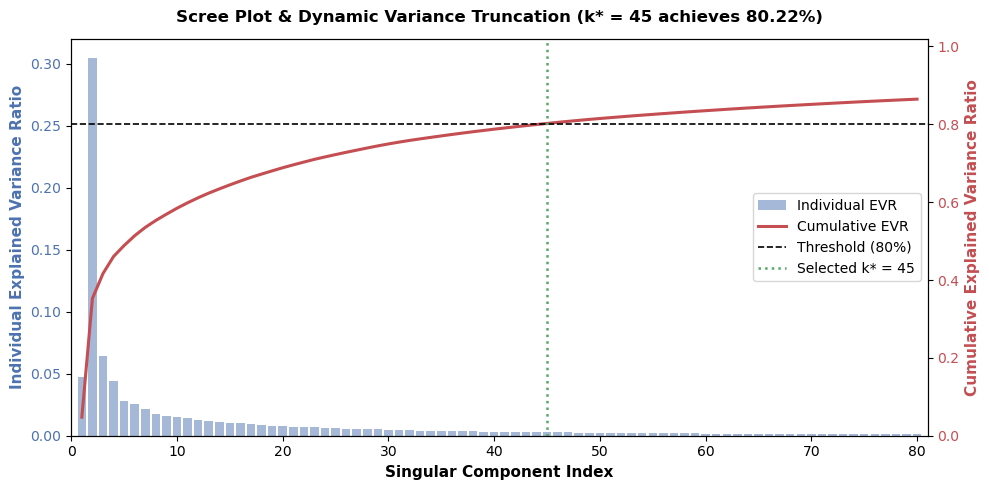

In [55]:
# 11.5 Dynamic TruncatedSVD (>= 80% Variance Threshold) & Scree Plot (V3)
from sklearn.decomposition import TruncatedSVD
import matplotlib.pyplot as plt

# Initial fit with generous component pool
MAX_COMPONENTS = min(80, len(all_selected_crm_cols))
svd_pool = TruncatedSVD(n_components=MAX_COMPONENTS, algorithm='randomized', random_state=42)

X_train_sparse = sp.csr_matrix(train[all_selected_crm_cols].to_numpy(dtype=np.float32))
X_test_sparse = sp.csr_matrix(test[all_selected_crm_cols].to_numpy(dtype=np.float32))

print(f'Fitting TruncatedSVD pool ({MAX_COMPONENTS} components) strictly on train (memory-efficient CSR format)...')
train_svd_pool = svd_pool.fit_transform(X_train_sparse)

cum_var = np.cumsum(svd_pool.explained_variance_ratio_)
VAR_THRESHOLD = 0.80

# Dynamic selection of components needed to reach >= 80%
if np.any(cum_var >= VAR_THRESHOLD):
    n_optimal = int(np.argmax(cum_var >= VAR_THRESHOLD) + 1)
else:
    n_optimal = MAX_COMPONENTS
    
print(f'Dynamic SVD Selection: k* = {n_optimal} components required to reach >= {VAR_THRESHOLD:.0%} cumulative variance')
print(f'Actual Cumulative Explained Variance at k*={n_optimal}: {cum_var[n_optimal-1]:.4%}')

# Dual Scree Plot & Cumulative Variance Plot
fig, ax1 = plt.subplots(figsize=(10, 5))

color_bar = '#4C72B0'
ax1.set_xlabel('Singular Component Index', fontsize=11, fontweight='semibold')
ax1.set_ylabel('Individual Explained Variance Ratio', color=color_bar, fontsize=11, fontweight='semibold')
ax1.bar(range(1, MAX_COMPONENTS + 1), svd_pool.explained_variance_ratio_, color=color_bar, alpha=0.5, label='Individual EVR')
ax1.tick_params(axis='y', labelcolor=color_bar)
ax1.set_xlim(0, MAX_COMPONENTS + 1)

ax2 = ax1.twinx()
color_curve = '#C44E52'
ax2.set_ylabel('Cumulative Explained Variance Ratio', color=color_curve, fontsize=11, fontweight='semibold')
ax2.plot(range(1, MAX_COMPONENTS + 1), cum_var, color=color_curve, linewidth=2.2, label='Cumulative EVR')
ax2.axhline(VAR_THRESHOLD, color='black', linestyle='--', linewidth=1.2, label=f'Threshold ({VAR_THRESHOLD:.0%})')
ax2.axvline(n_optimal, color='#55A868', linestyle=':', linewidth=1.8, label=f'Selected k* = {n_optimal}')
ax2.tick_params(axis='y', labelcolor=color_curve)
ax2.set_ylim(0, 1.02)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', frameon=True)

plt.title(f'Scree Plot & Dynamic Variance Truncation (k* = {n_optimal} achieves {cum_var[n_optimal-1]:.2%})', 
          fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

# Truncate train and test projections to optimal k* components
svd_cols = [f'SVD_COMP_{i+1}' for i in range(n_optimal)]
train_svd_df = pd.DataFrame(train_svd_pool[:, :n_optimal], columns=svd_cols, index=train.index)
test_svd = svd_pool.transform(X_test_sparse)[:, :n_optimal]
test_svd_df = pd.DataFrame(test_svd, columns=svd_cols, index=test.index)

save(pd.DataFrame({
    'component': svd_cols,
    'explained_variance_ratio': svd_pool.explained_variance_ratio_[:n_optimal],
    'cumulative_variance_ratio': cum_var[:n_optimal]
}), 'svd_variance_explained_v2.csv');


### 11.6 Assemble and Export Clean Datasets (V2)

We assemble and export the clean datasets for Sprint 2 with `_v2` nomenclature:
- `train_clean_v2.csv`: Filtered CRM features + SVD latent components + MSISDN.
- `train_targets_v2.csv`: Target matrix $Y_{\text{model}}$ (non-additive targets, without label overwriting).
- `test_clean_v2.csv`: Aligned test features + SVD latent components + MSISDN.
- `additive_rules_v2.json`: Deterministic rules for reconstructing $Y_{\text{additive}}$.


In [56]:
# 11.6 Assemble & Export (V2)
train_clean_v2 = pd.concat([train[['MSISDN']], train[all_selected_crm_cols], train_svd_df], axis=1)
test_clean_v2 = pd.concat([test[['MSISDN']], test[all_selected_crm_cols], test_svd_df], axis=1)
train_targets_v2 = pd.concat([train[['MSISDN']], train[bil_cols_model]], axis=1)

print('train_clean_v2 shape:', train_clean_v2.shape)
print('test_clean_v2 shape:', test_clean_v2.shape)
print('train_targets_v2 shape:', train_targets_v2.shape)

# Assertions to ensure zero leakage and schema alignment
assert list(train_clean_v2.columns) == list(test_clean_v2.columns), 'Train and Test schemas mismatch'
assert train_clean_v2.isna().sum().sum() == 0, 'Nulls in train_clean_v2'
assert test_clean_v2.isna().sum().sum() == 0, 'Nulls in test_clean_v2'

train_clean_v2.to_csv(f'{DATA_DIR}/train_clean_v2.csv', index=False)
test_clean_v2.to_csv(f'{DATA_DIR}/test_clean_v2.csv', index=False)
train_targets_v2.to_csv(f'{DATA_DIR}/train_targets_v2.csv', index=False)

print(f'Successfully exported clean V2 datasets to {DATA_DIR}/')


train_clean_v2 shape: (187442, 788)
test_clean_v2 shape: (97100, 788)
train_targets_v2 shape: (187442, 690)
Successfully exported clean V2 datasets to ../data/


## 12. Multi-Label Baseline Modeling Architecture & Post-Processing Reconstruction


Below we define:
1. **Multi-Label Baseline Pipeline (Binary Relevance with LightGBM).**
2. **Deterministic Post-Processing:** Reconstructs the 125 additive billing columns using the rules identified in Section 11.2 without DataFrame fragmentation.
3. **Multi-Label Evaluation Suite:** Evaluates predictions using ROC-AUC (Macro/Micro), PR-AUC, F1-Score (Micro/Macro), and Exact Match Ratio (Subset Accuracy / EMR).


In [57]:
# 12. Multi-Label Modeling & Deterministic Post-Processing Reconstruction
from sklearn.metrics import roc_auc_score, f1_score
import lightgbm as lgb

def reconstruct_full_predictions(y_model_pred_df, test_features_df, bil_to_crm_triggers, all_bil_cols):
    """
    Recombines model predictions on Y_model with deterministic rules on Y_additive.
    y_model_pred_df: DataFrame with predictions for bil_cols_model
    test_features_df: DataFrame with CRM features (must contain original CRM packs)
    bil_to_crm_triggers: dict mapping bil_pack -> list of crm_packs
    all_bil_cols: complete ordered list of 731 original BIL columns
    """
    # Build additive columns in a single dict to avoid DataFrame fragmentation
    additive_dict = {}
    for b_pack, c_packs in bil_to_crm_triggers.items():
        avail_c = [c for c in c_packs if c in test_features_df.columns]
        if avail_c:
            additive_dict[b_pack] = test_features_df[avail_c].max(axis=1).values
        else:
            additive_dict[b_pack] = np.zeros(len(test_features_df), dtype=np.int8)
            
    additive_df = pd.DataFrame(additive_dict, index=test_features_df.index)
    
    # Concatenate ML model predictions and additive predictions, then reorder to original target schema
    full_preds = pd.concat([y_model_pred_df, additive_df], axis=1)
    return full_preds.reindex(columns=all_bil_cols, fill_value=0)

def evaluate_multilabel_performance(y_true, y_pred_prob, threshold=0.5):
    """
    Computes rigorous Multi-Label metrics: Macro/Micro ROC-AUC, Micro/Macro F1, and Exact Match Ratio.
    """
    y_true_np = np.asarray(y_true)
    y_pred_bin = (np.asarray(y_pred_prob) >= threshold).astype(int)
    
    metrics = {}
    try:
        metrics['roc_auc_micro'] = roc_auc_score(y_true_np, y_pred_prob, average='micro')
        metrics['roc_auc_macro'] = roc_auc_score(y_true_np, y_pred_prob, average='macro')
    except Exception as e:
        metrics['roc_auc_note'] = str(e)
        
    metrics['f1_micro'] = f1_score(y_true_np, y_pred_bin, average='micro')
    metrics['f1_macro'] = f1_score(y_true_np, y_pred_bin, average='macro')
    # Exact Match Ratio (EMR) / Subset Accuracy
    metrics['exact_match_ratio'] = np.all(y_true_np == y_pred_bin, axis=1).mean()
    
    return metrics

print('Multi-Label architecture and post-processing reconstructor successfully defined.')


Multi-Label architecture and post-processing reconstructor successfully defined.


### Export Manifest (V2)

The complete updated manifest of all files generated by both Section 10 and Section 11 is compiled and registered below.


In [58]:
# Manifest V2
manifest_v2 = pd.DataFrame(EXPORTS).drop_duplicates('file', keep='last').reset_index(drop=True)
manifest_v2.to_csv(f'{DERIVED_DIR}/_manifest_v2.csv', index=False)
print(f'{len(manifest_v2)} derived files registered in manifest V2.')
display(manifest_v2.tail(20))


47 derived files registered in manifest V2.


,file,rows,cols
27,pca_variance_concentration.csv,5,4
28,pca_component_vs_pack_count.csv,6,2
29,coclustering_quality.csv,5,6
30,pack_community_quality.csv,3,5
31,pack_communities.csv,116,3
32,customer_cluster_silhouette.csv,5,3
33,customer_segments.csv,8,5
34,bil_top_configs.csv,15,3
35,config_coverage_summary.csv,4,4
36,segment_pack_averages.csv,4,6
